In [3]:
# ── CELL 1: Clone / pull repo and verify k-fold files exist ──────────────────
 
import subprocess, os, sys
 
REPO_URL = 'https://github.com/akshlabh/amr-5-class.git'
WORK_DIR = '/kaggle/working/amr-5-class'
DATASET  = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'
 
if os.path.exists(WORK_DIR):
    print("Repo already cloned — pulling latest")
    subprocess.run(['git', '-C', WORK_DIR, 'pull'], check=True)
else:
    print("Cloning repo ...")
    subprocess.run(['git', 'clone', REPO_URL, WORK_DIR], check=True)
 
os.chdir(WORK_DIR)
print(f"\nWorking directory: {os.getcwd()}")
 
# Check all files needed for k-fold run
for path in [
    'src/train_kfold.py',
    'src/dataset.py',
    'src/models/mcldnn.py',
    'src/models/mcldnn_attention.py',
    'src/utils/mltools.py',
    'src/utils/seed.py',
    'configs/exp_5class_baseline_kfold.yaml',
    'configs/exp_5class_attention_kfold.yaml',
]:
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f"  {status}  {path}")
 

Repo already cloned — pulling latest
Already up to date.

Working directory: /kaggle/working/amr-5-class
  ✓  src/train_kfold.py
  ✓  src/dataset.py
  ✓  src/models/mcldnn.py
  ✓  src/models/mcldnn_attention.py
  ✓  src/utils/mltools.py
  ✓  src/utils/seed.py
  ✓  configs/exp_5class_baseline_kfold.yaml
  ✓  configs/exp_5class_attention_kfold.yaml


In [4]:

# ── CELL 2: Quick dataset sanity-check (same as attention-mech.ipynb Cell 1) ─
 
import pickle, sys
sys.path.insert(0, WORK_DIR)
 
print(f"Loading dataset from: {DATASET}")
with open(DATASET, 'rb') as f:
    Xd = pickle.load(f, encoding='iso-8859-1')
 
all_mods = sorted(set(k[0] for k in Xd.keys()))
all_snrs = sorted(set(k[1] for k in Xd.keys()))
 
print(f"\nAll modulations : {all_mods}")
print(f"All SNRs        : {all_snrs}  ({len(all_snrs)} levels)")
print(f"\nSamples per (mod, snr): {Xd[(all_mods[0], all_snrs[0])].shape}")
 
TARGET_CLASSES = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
n_total = len(TARGET_CLASSES) * len(all_snrs) * 1000
print(f"\n5-class k-fold split breakdown:")
print(f"  {len(TARGET_CLASSES)} classes × {len(all_snrs)} SNRs × 1 000 samples = {n_total:,} total")
print(f"  Test  (held-out, 20 %): {n_total * 20 // 100:,}  samples  — locked in FIRST, never used during training")
print(f"  TrainVal (80 %)       : {n_total * 80 // 100:,}  samples  — rotated across 5 folds")
print(f"    Per fold  val       : {n_total * 80 // 100 // 5:,}  samples")
print(f"    Per fold  train     : {n_total * 80 // 100 * 4 // 5:,}  samples")
del Xd
 

Loading dataset from: /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat

All modulations : ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
All SNRs        : [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]  (20 levels)

Samples per (mod, snr): (1000, 2, 128)

5-class k-fold split breakdown:
  5 classes × 20 SNRs × 1 000 samples = 100,000 total
  Test  (held-out, 20 %): 20,000  samples  — locked in FIRST, never used during training
  TrainVal (80 %)       : 80,000  samples  — rotated across 5 folds
    Per fold  val       : 16,000  samples
    Per fold  train     : 64,000  samples


In [13]:

# ── CELL 3: Train MCLDNN BASELINE — 5-Fold CV ────────────────────────────────
 
import os
os.chdir('/kaggle/working/amr-5-class')
 
print("=" * 60)
print("  K-FOLD CV — MCLDNN BASELINE (5 folds)")
print("=" * 60)
 
get_ipython().system(
    f"python src/train_kfold.py "
    f"--config configs/exp_5class_baseline_kfold.yaml "
    f"--datasetpath {DATASET}"
)
 
# Verify outputs
import glob
fold_files = glob.glob('experiments/5class_baseline_kfold/kfold/fold_*/metrics.json')
print(f"\n{'✓' if len(fold_files) == 5 else '✗'} "
      f"Found {len(fold_files)}/5 fold metric files")
 
summary_path = 'experiments/5class_baseline_kfold/kfold/summary.json'
if os.path.exists(summary_path):
    import json
    with open(summary_path) as f:
        s = json.load(f)
    print(f"✓ Baseline k-fold summary: mean_val_acc = {s['mean_val_acc']:.4f} ± {s['std_val_acc']:.4f}")
    print(f"  Best fold: fold_{s['best_fold']}")
else:
    print("✗ summary.json not found — check training output above")
 

  K-FOLD CV — MCLDNN BASELINE (5 folds)
2026-06-21 19:21:50.352494: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782069710.536765     135 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782069710.595268     135 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782069711.030333     135 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782069711.030406     135 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782069711.030419     135 computati

In [5]:

# ── CELL 4: Train MCLDNN-ATTENTION — 5-Fold CV ───────────────────────────────
 
import os
os.chdir('/kaggle/working/amr-5-class')
 
print("=" * 60)
print("  K-FOLD CV — MCLDNN-ATTENTION (5 folds)")
print("=" * 60)
 
get_ipython().system(
    f"python src/train_kfold.py "
    f"--config configs/exp_5class_attention_kfold.yaml "
    f"--datasetpath {DATASET}"
)
 
# Verify outputs
import glob
fold_files = glob.glob('experiments/5class_attention_kfold/kfold/fold_*/metrics.json')
print(f"\n{'✓' if len(fold_files) == 5 else '✗'} "
      f"Found {len(fold_files)}/5 fold metric files")
 
summary_path = 'experiments/5class_attention_kfold/kfold/summary.json'
if os.path.exists(summary_path):
    import json
    with open(summary_path) as f:
        s = json.load(f)
    print(f"✓ Attention k-fold summary: mean_val_acc = {s['mean_val_acc']:.4f} ± {s['std_val_acc']:.4f}")
    print(f"  Best fold: fold_{s['best_fold']}")
else:
    print("✗ summary.json not found — check training output above")
 

  K-FOLD CV — MCLDNN-ATTENTION (5 folds)
2026-06-21 21:40:51.046996: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782078051.239623     138 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782078051.292204     138 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782078051.753905     138 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782078051.753948     138 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782078051.753952     138 computat

In [6]:

# ── CELL 5: Load summaries + per-SNR test CSVs, print comparison table ────────
 
import os, json, numpy as np, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
 
os.chdir('/kaggle/working/amr-5-class')
os.makedirs('experiments/comparison_kfold', exist_ok=True)
 
# ── Load k-fold summaries ─────────────────────────────────────────────────────
summaries = {}
for tag, exp in [('Baseline', '5class_baseline_kfold'),
                 ('Attention', '5class_attention_kfold')]:
    path = f'experiments/{exp}/kfold/summary.json'
    if not os.path.exists(path):
        print(f"[SKIP] {tag} summary not found: {path}")
        continue
    with open(path) as f:
        summaries[tag] = json.load(f)
 
print("=" * 60)
print("  K-FOLD CROSS-VALIDATION SUMMARY")
print("=" * 60)
for tag, s in summaries.items():
    print(f"\n  {tag}  ({s['n_folds']}-fold)")
    for r in s['fold_results']:
        print(f"    Fold {r['fold']} | val_acc={r['val_acc']:.4f} "
              f"| val_loss={r['val_loss']:.4f} | best_epoch={r['best_epoch']}")
    print(f"    {'─'*40}")
    print(f"    Mean val_acc : {s['mean_val_acc']:.4f} ± {s['std_val_acc']:.4f}")
    print(f"    Best fold    : fold_{s['best_fold']}")
 
# ── Load per-SNR test CSVs from best-fold test evaluations ────────────────────
snr_accs = {}
for tag, exp in [('Baseline', '5class_baseline_kfold'),
                 ('Attention', '5class_attention_kfold')]:
    csv_path = f'experiments/{exp}/kfold/test/acc_per_snr.csv'
    if not os.path.exists(csv_path):
        print(f"[SKIP] {tag} per-SNR CSV not found: {csv_path}")
        continue
    df = pd.read_csv(csv_path)
    snr_accs[tag] = dict(zip(df['snr'].astype(int), df['accuracy']))
 
ALL_SNRS = sorted(snr_accs.get('Baseline', snr_accs.get('Attention', {0: 0})).keys())
 
print(f"\n{'='*60}")
print(f"  TEST SET COMPARISON (best-fold model per experiment)")
print(f"  (same block-stratified 20% held-out set — evaluated ONCE)")
print(f"{'='*60}")
names = list(snr_accs.keys())
header = f"  {'SNR':>6}"
for n in names:
    header += f"  {n:>16}"
print(header)
for snr in ALL_SNRS:
    row = f"  {snr:>5} dB"
    for n in names:
        row += f"  {snr_accs[n].get(snr, float('nan'))*100:>15.2f}%"
    print(row)
print(f"  {'─'*50}")
row = f"  {'Mean':>6}"
for n in names:
    vals = [snr_accs[n][s] for s in ALL_SNRS if s in snr_accs[n]]
    row += f"  {np.mean(vals)*100:>15.2f}%"
print(row)
 
# ── Save merged per-SNR CSV ───────────────────────────────────────────────────
if len(names) == 2:
    df_merged = pd.DataFrame({
        'snr': ALL_SNRS,
        'acc_baseline':  [snr_accs[names[0]].get(s, np.nan) for s in ALL_SNRS],
        'acc_attention': [snr_accs[names[1]].get(s, np.nan) for s in ALL_SNRS],
    })
    df_merged['delta'] = df_merged['acc_attention'] - df_merged['acc_baseline']
    df_merged.to_csv('experiments/comparison_kfold/kfold_test_per_snr.csv', index=False)
    print(f"\n[SAVED] experiments/comparison_kfold/kfold_test_per_snr.csv")
 
# ── Also print the full k-fold summary side-by-side ──────────────────────────
if len(summaries) == 2:
    tags = list(summaries.keys())
    df_folds = pd.DataFrame({
        'fold': [r['fold'] for r in summaries[tags[0]]['fold_results']],
        f'val_acc_{tags[0]}':  [r['val_acc'] for r in summaries[tags[0]]['fold_results']],
        f'val_acc_{tags[1]}':  [r['val_acc'] for r in summaries[tags[1]]['fold_results']],
    })
    df_folds['delta'] = df_folds[f'val_acc_{tags[1]}'] - df_folds[f'val_acc_{tags[0]}']
    df_folds.to_csv('experiments/comparison_kfold/kfold_val_per_fold.csv', index=False)
    print(f"[SAVED] experiments/comparison_kfold/kfold_val_per_fold.csv")
 

  K-FOLD CROSS-VALIDATION SUMMARY

  Baseline  (5-fold)
    Fold 0 | val_acc=0.5759 | val_loss=0.9946 | best_epoch=81
    Fold 1 | val_acc=0.5734 | val_loss=0.9353 | best_epoch=84
    Fold 2 | val_acc=0.6386 | val_loss=0.9899 | best_epoch=101
    Fold 3 | val_acc=0.5822 | val_loss=1.0720 | best_epoch=93
    Fold 4 | val_acc=0.6229 | val_loss=1.1966 | best_epoch=104
    ────────────────────────────────────────
    Mean val_acc : 0.5986 ± 0.0268
    Best fold    : fold_2

  Attention  (5-fold)
    Fold 0 | val_acc=0.5643 | val_loss=1.1743 | best_epoch=34
    Fold 1 | val_acc=0.5869 | val_loss=1.1614 | best_epoch=38
    Fold 2 | val_acc=0.5719 | val_loss=1.1302 | best_epoch=35
    Fold 3 | val_acc=0.6127 | val_loss=1.1471 | best_epoch=59
    Fold 4 | val_acc=0.6031 | val_loss=1.1501 | best_epoch=40
    ────────────────────────────────────────
    Mean val_acc : 0.5878 ± 0.0182
    Best fold    : fold_3

  TEST SET COMPARISON (best-fold model per experiment)
  (same block-stratified 20% he

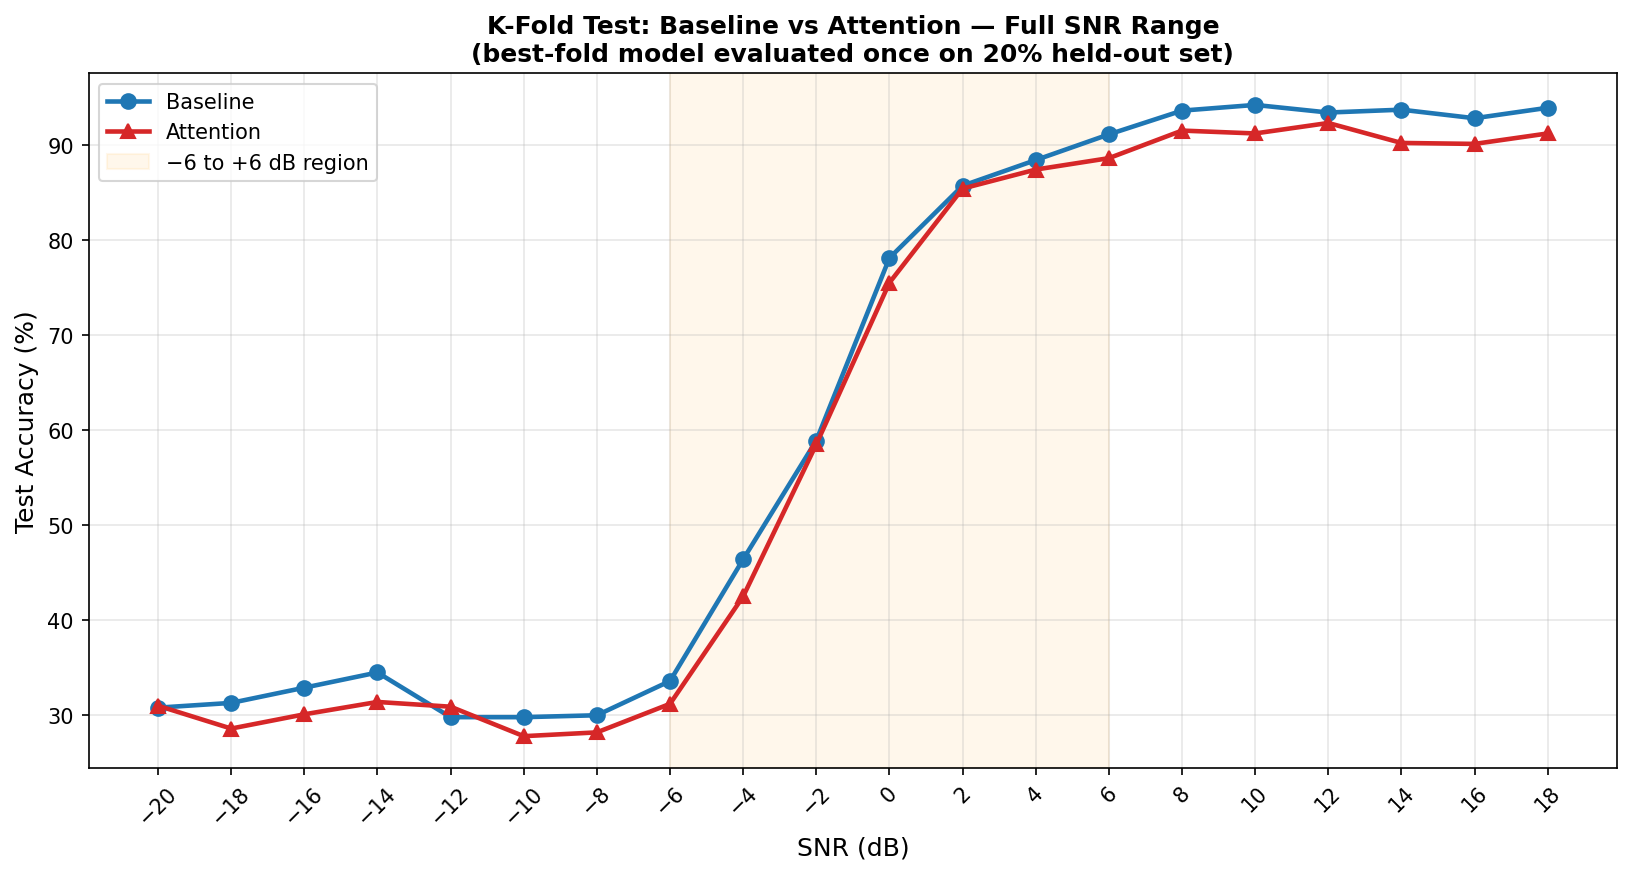

[SAVED] experiments/comparison_kfold/kfold_full_snr_comparison.png


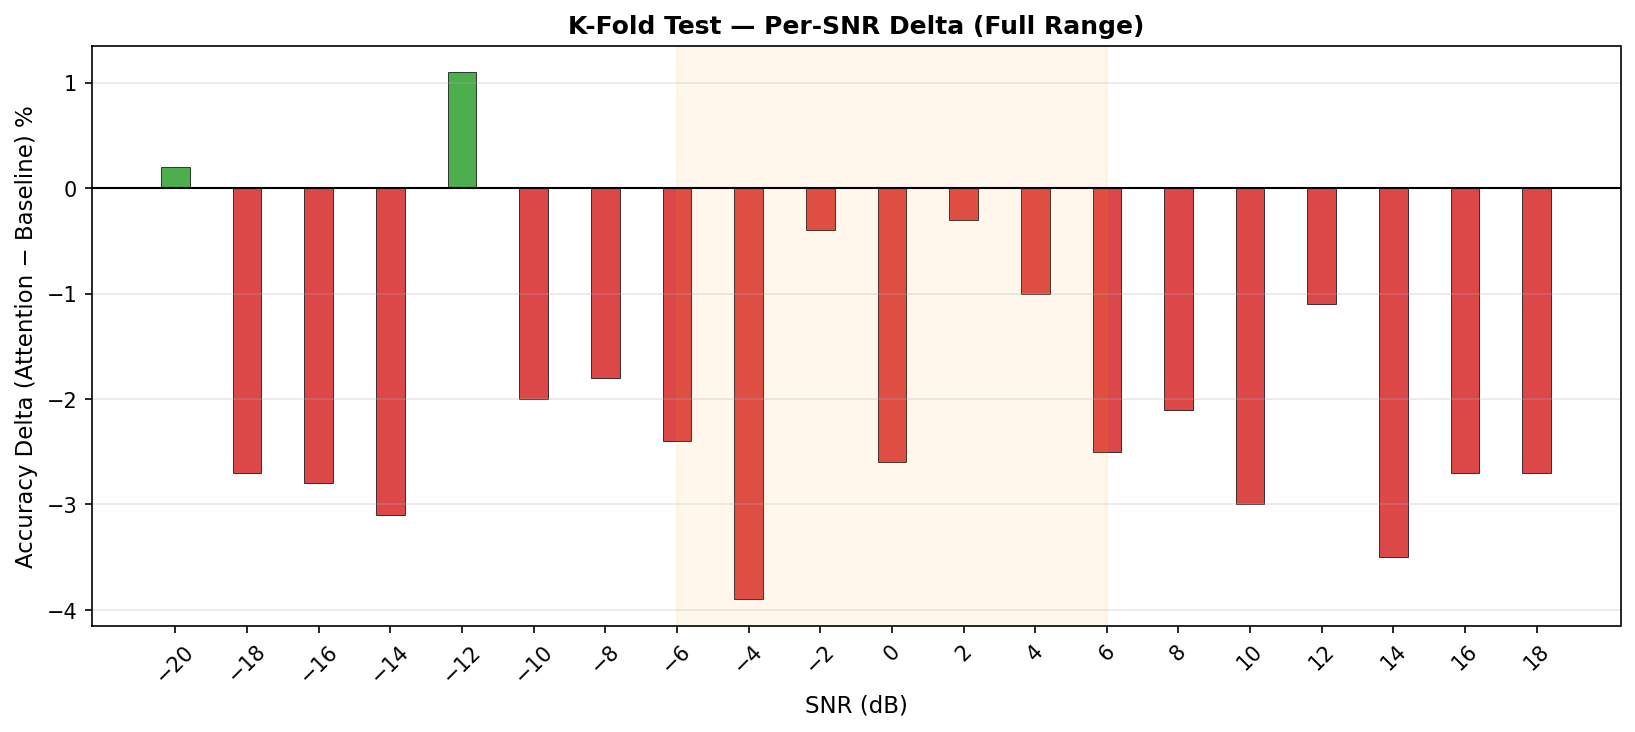

[SAVED] experiments/comparison_kfold/kfold_full_snr_delta.png


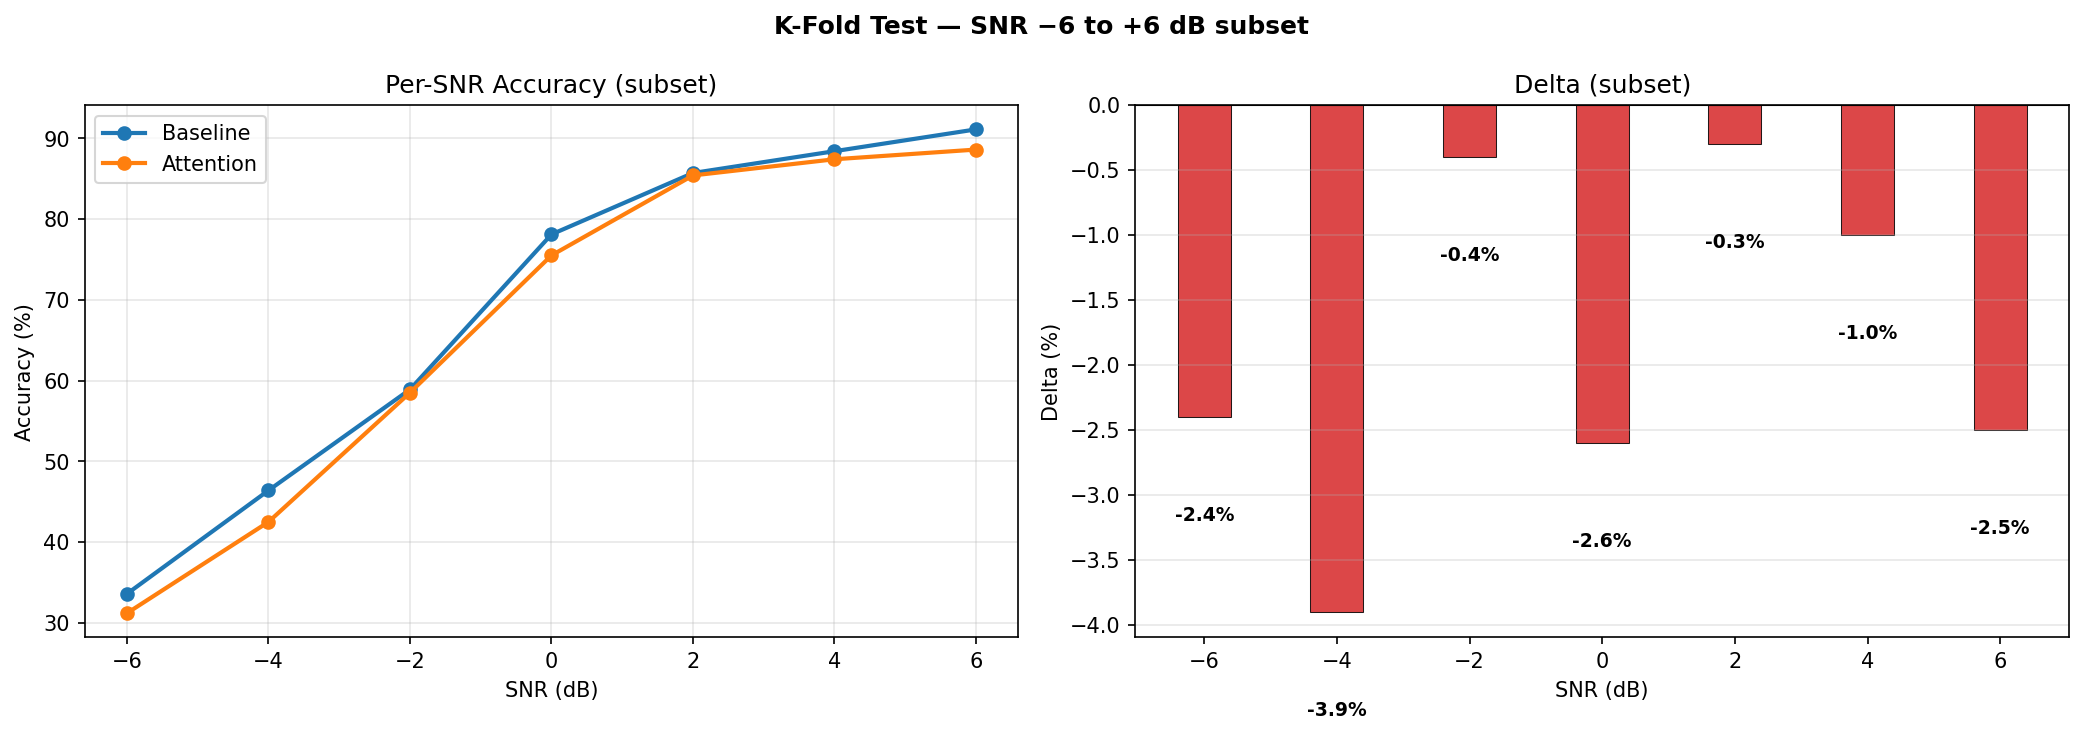

[SAVED] experiments/comparison_kfold/kfold_subset_minus6_to_6.png


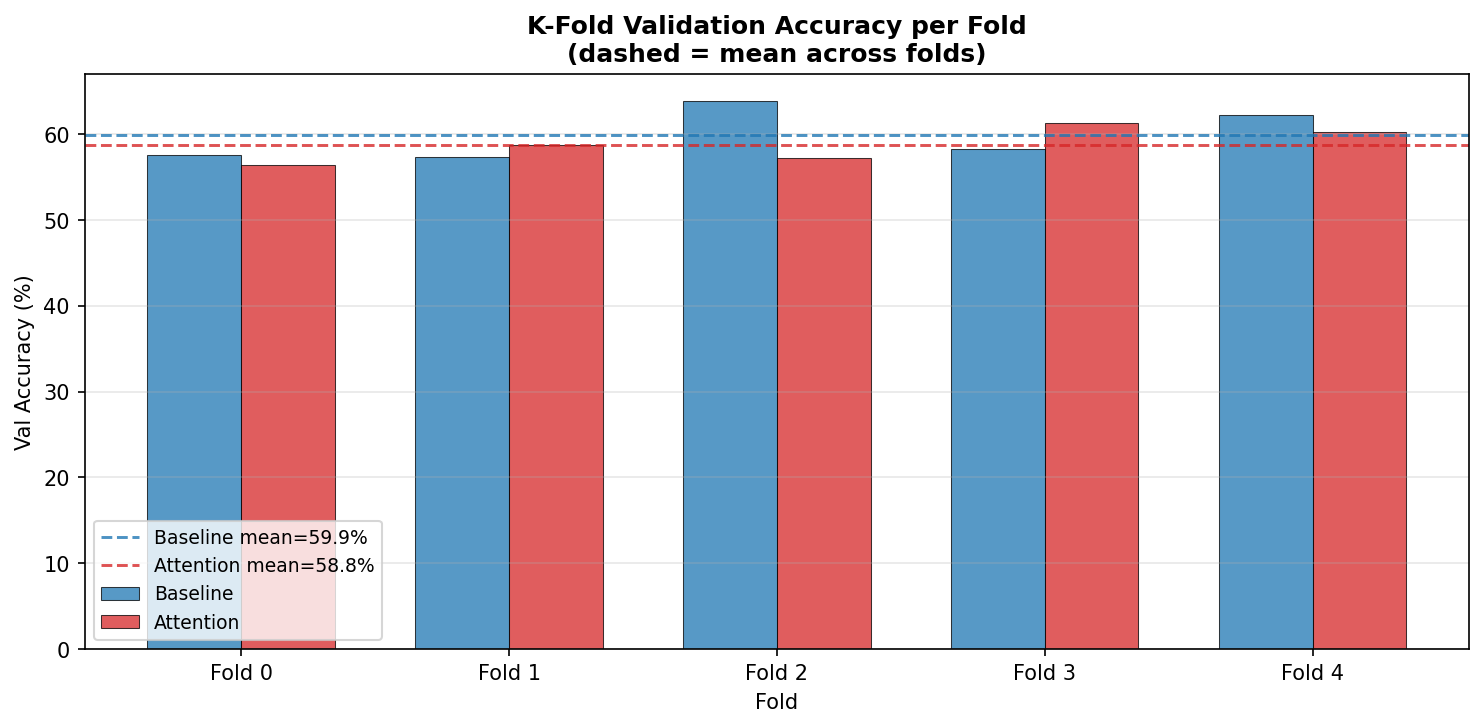

[SAVED] experiments/comparison_kfold/kfold_per_fold_val_acc.png

── Baseline — per-fold validation confusion matrices ──
  Fold 0


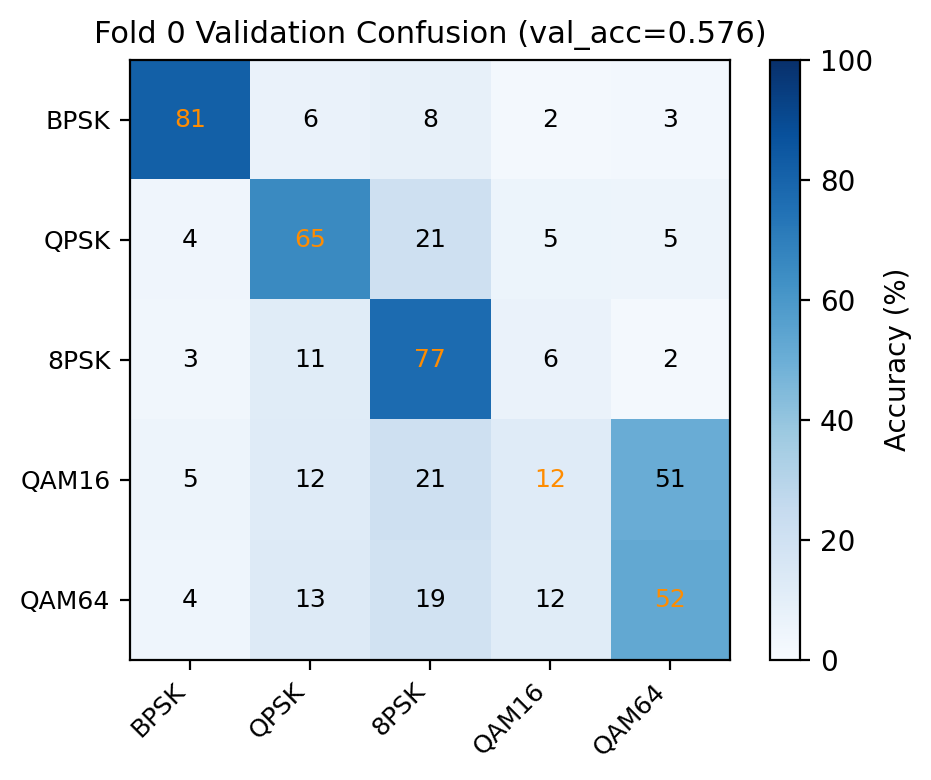

  Fold 1


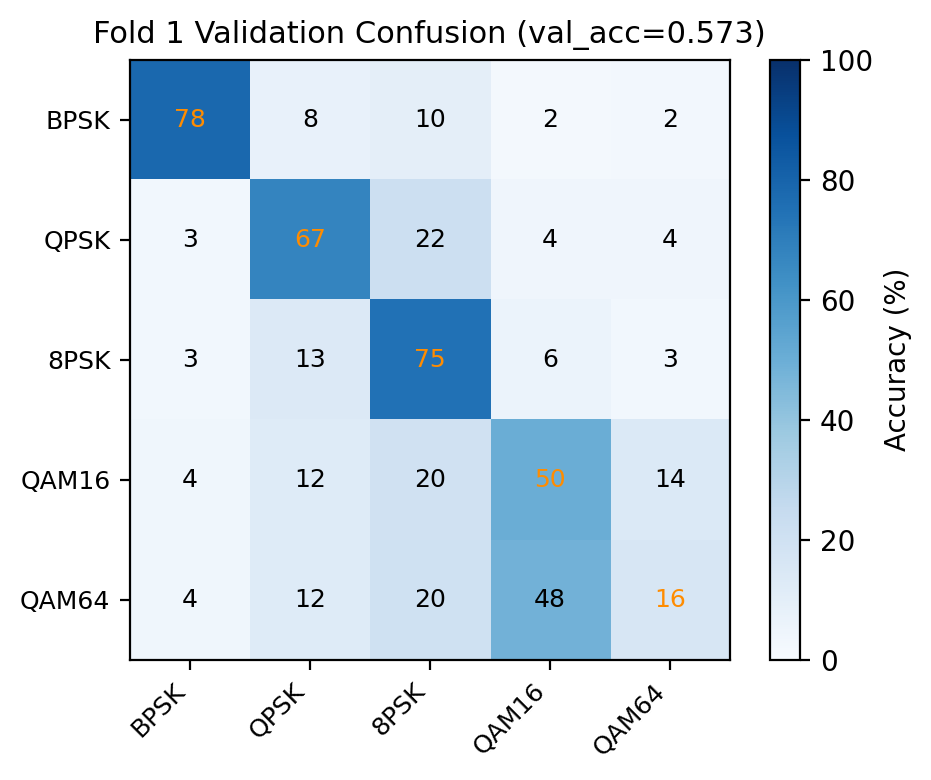

  Fold 2 ← best fold


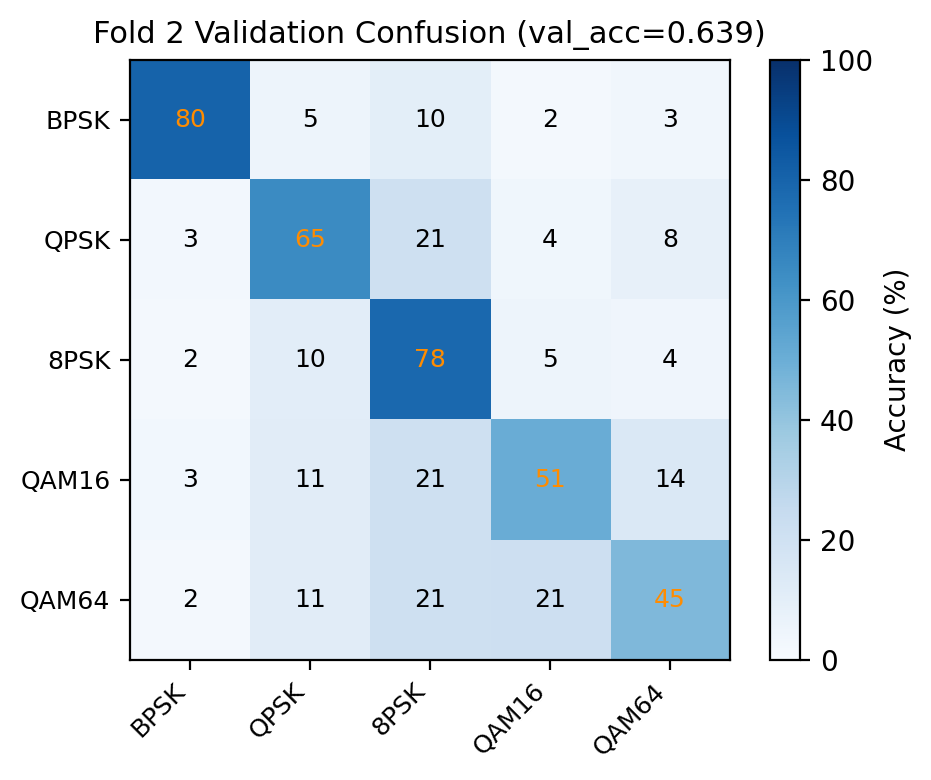

  Fold 3


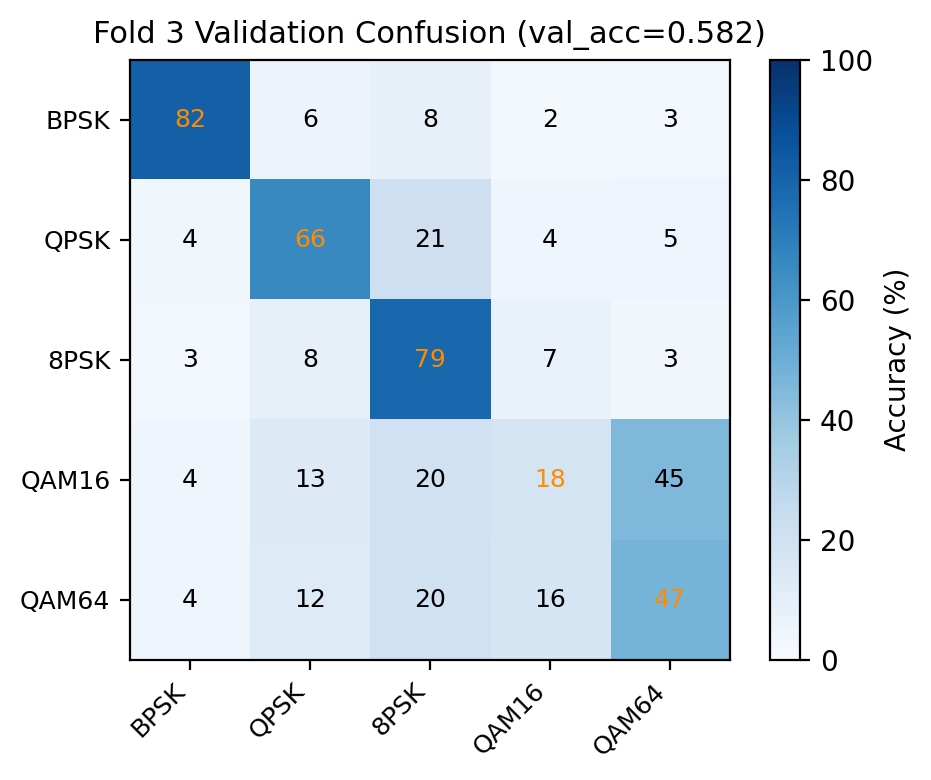

  Fold 4


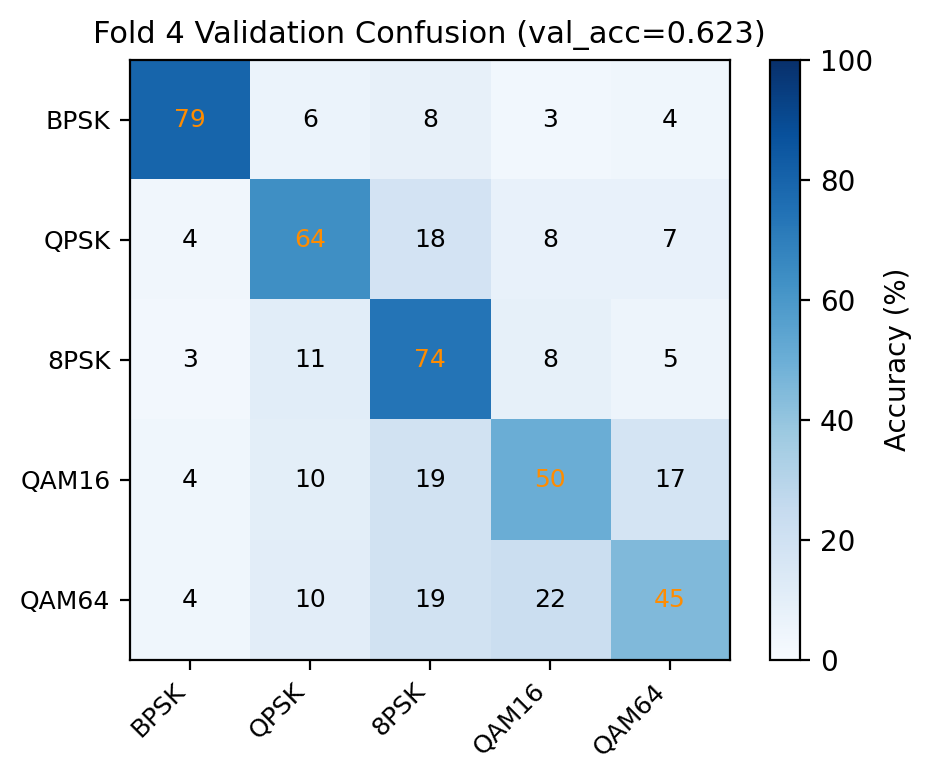


── Attention — per-fold validation confusion matrices ──
  Fold 0


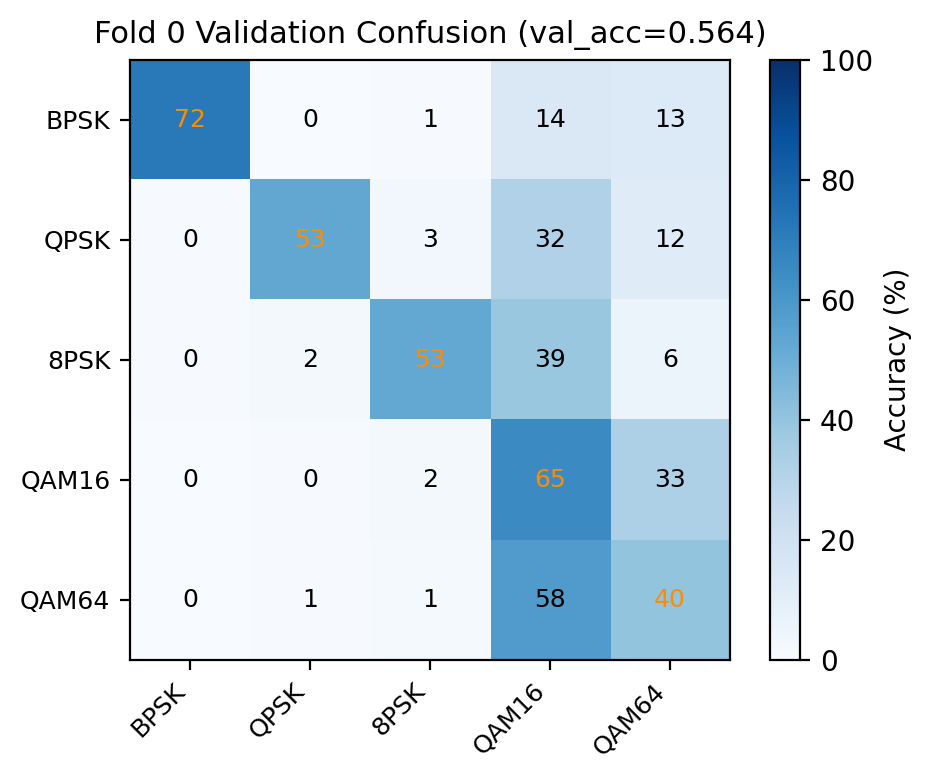

  Fold 1


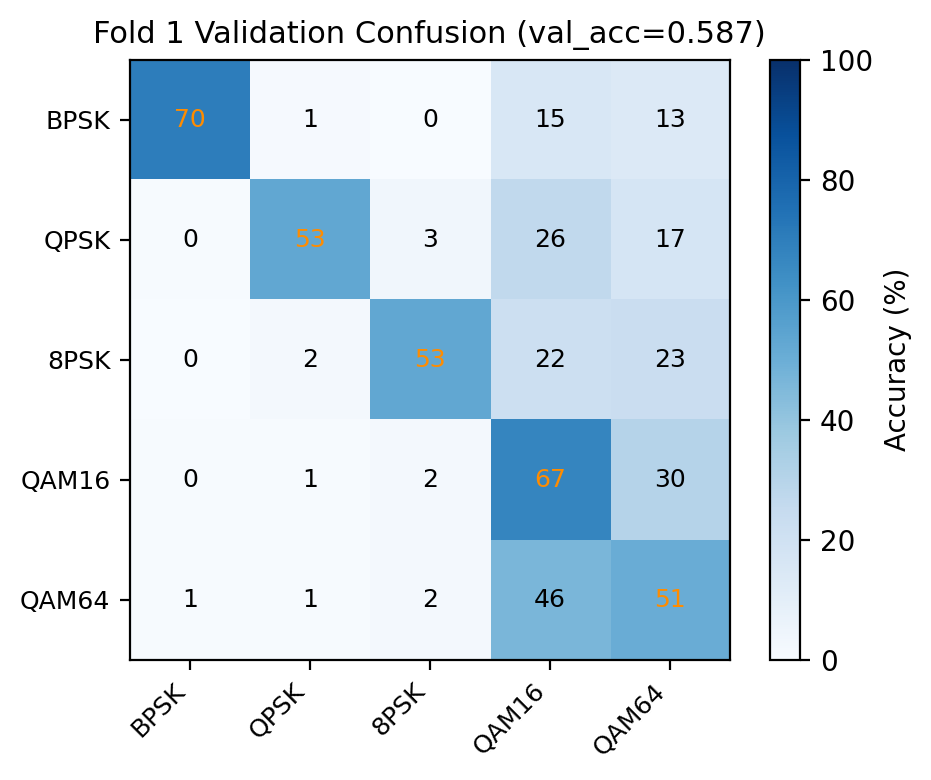

  Fold 2


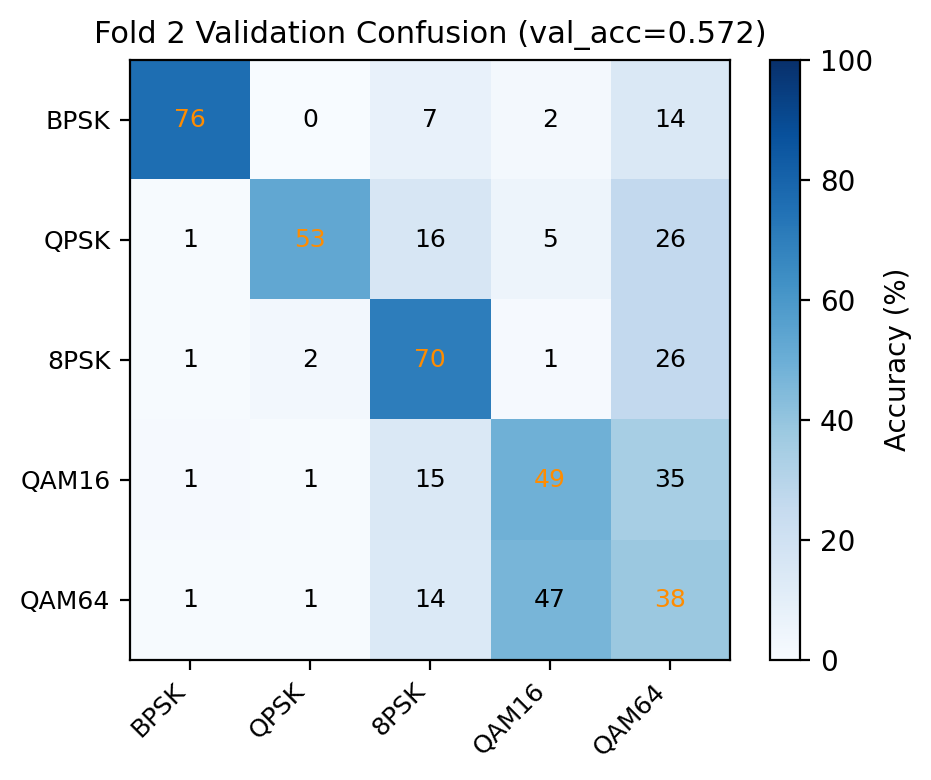

  Fold 3 ← best fold


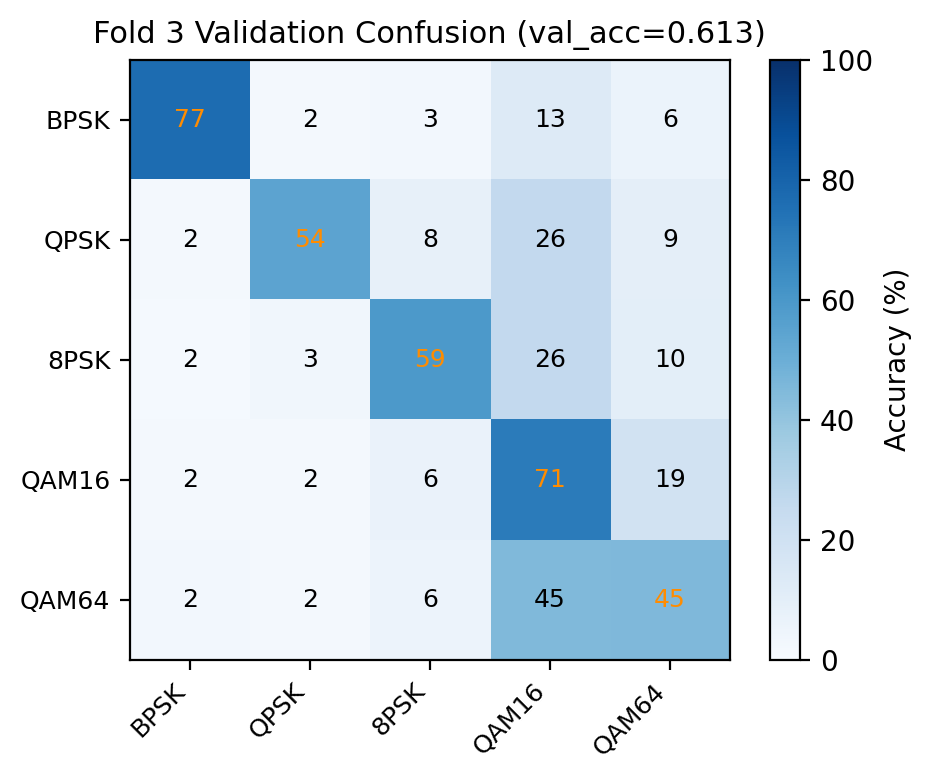

  Fold 4


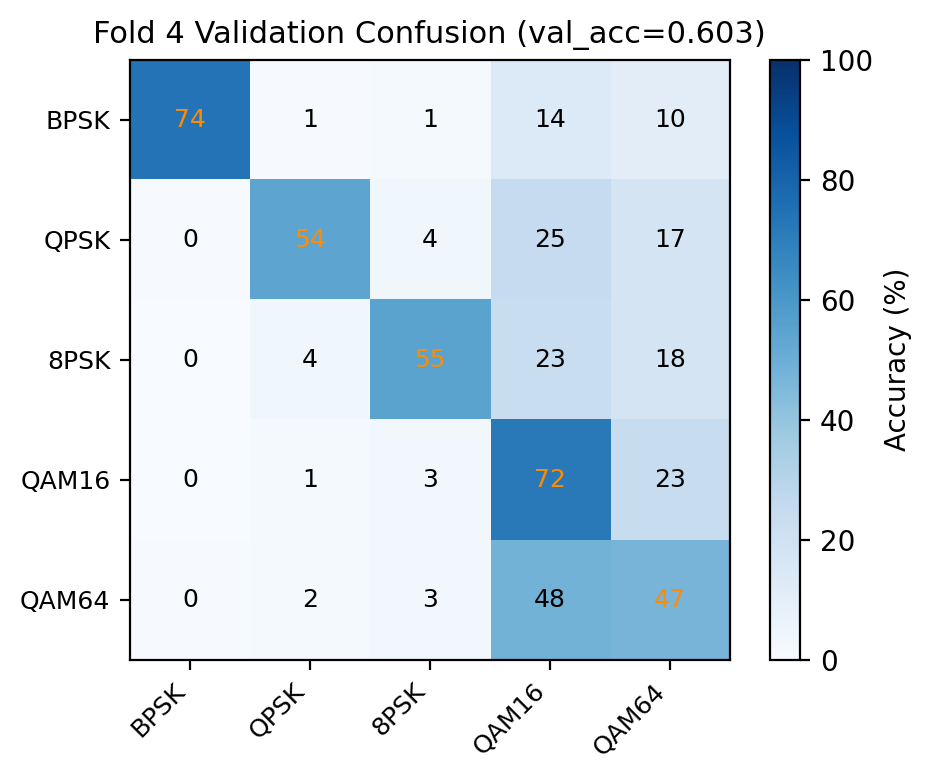


── Test confusion matrices (best-fold models) ──
  Baseline


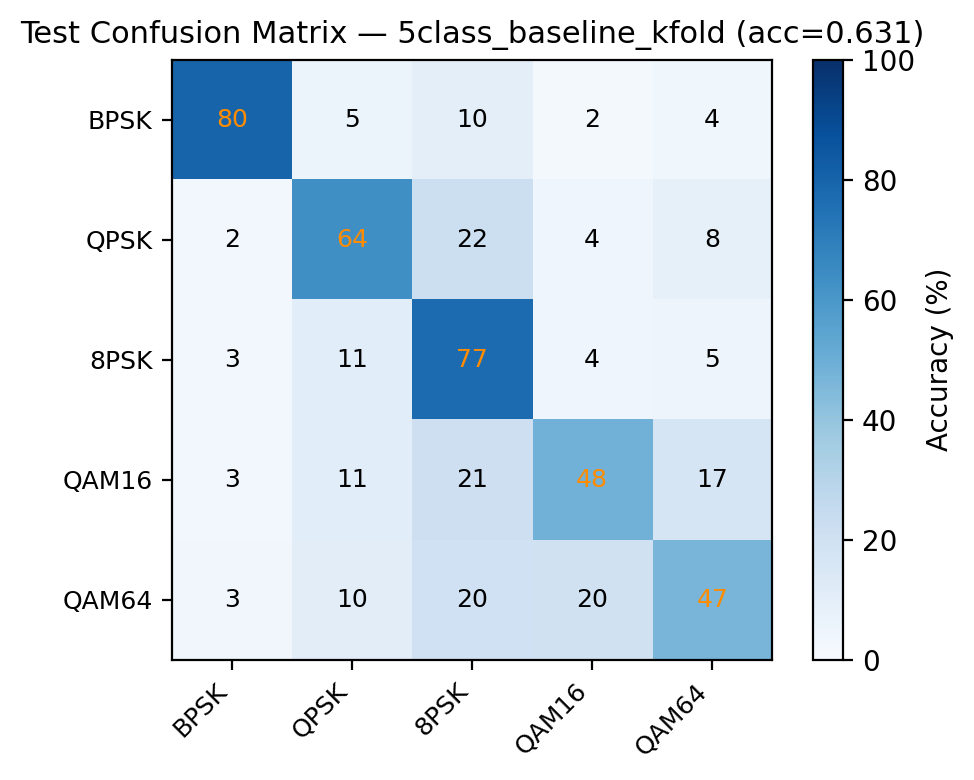

  Attention


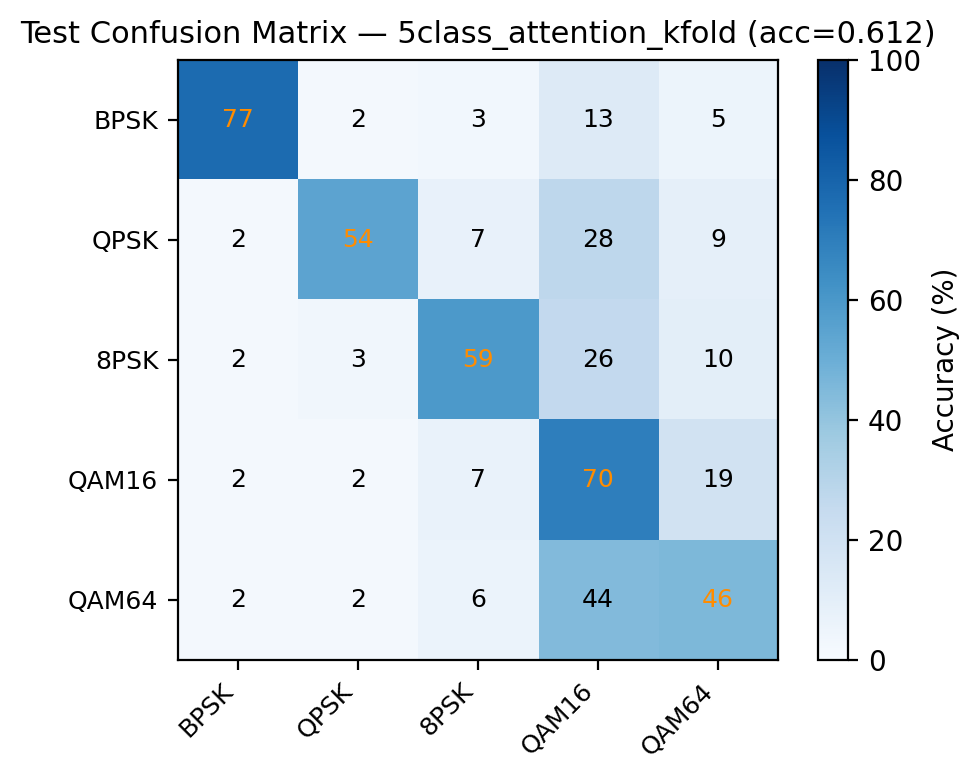

In [7]:

# ── CELL 6: Plots ─────────────────────────────────────────────────────────────
 
import os, json, numpy as np, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
 
os.chdir('/kaggle/working/amr-5-class')
os.makedirs('experiments/comparison_kfold', exist_ok=True)
 
STYLE = {
    'Baseline':  {'color': '#1f77b4', 'marker': 'o'},
    'Attention': {'color': '#d62728', 'marker': '^'},
}
 
# Re-load in case this cell runs standalone
if 'snr_accs' not in dir() or not snr_accs:
    snr_accs = {}
    for tag, exp in [('Baseline', '5class_baseline_kfold'),
                     ('Attention', '5class_attention_kfold')]:
        csv_path = f'experiments/{exp}/kfold/test/acc_per_snr.csv'
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            snr_accs[tag] = dict(zip(df['snr'].astype(int), df['accuracy']))
 
if 'summaries' not in dir() or not summaries:
    summaries = {}
    for tag, exp in [('Baseline', '5class_baseline_kfold'),
                     ('Attention', '5class_attention_kfold')]:
        path = f'experiments/{exp}/kfold/summary.json'
        if os.path.exists(path):
            with open(path) as f:
                summaries[tag] = json.load(f)
 
ALL_SNRS = sorted(snr_accs.get('Baseline', snr_accs.get('Attention', {})).keys())
names    = list(snr_accs.keys())
 
# ── Plot 1: Full-SNR accuracy curves (k-fold test) ────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
for name in names:
    st = STYLE.get(name, {'color': 'gray', 'marker': 's'})
    ys = [snr_accs[name].get(s, np.nan) * 100 for s in ALL_SNRS]
    ax.plot(ALL_SNRS, ys, marker=st['marker'], color=st['color'],
            linewidth=2.2, markersize=7, label=name)
ax.axvspan(-6, 6, alpha=0.08, color='orange', label='−6 to +6 dB region')
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('K-Fold Test: Baseline vs Attention — Full SNR Range\n'
             '(best-fold model evaluated once on 20% held-out set)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(ALL_SNRS)
plt.xticks(rotation=45)
plt.tight_layout()
p1 = 'experiments/comparison_kfold/kfold_full_snr_comparison.png'
fig.savefig(p1, dpi=150, bbox_inches='tight')
plt.close()
display(Image(p1))
print(f"[SAVED] {p1}")
 
# ── Plot 2: Per-SNR delta (Attention − Baseline) ──────────────────────────────
csv_full = 'experiments/comparison_kfold/kfold_test_per_snr.csv'
if os.path.exists(csv_full):
    df = pd.read_csv(csv_full)
    fig, ax = plt.subplots(figsize=(11, 5))
    colors = ['#2ca02c' if d >= 0 else '#d62728' for d in df['delta']]
    ax.bar(df['snr'], df['delta'] * 100, color=colors, alpha=0.85,
           edgecolor='black', linewidth=0.4)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvspan(-6, 6, alpha=0.08, color='orange')
    ax.set_xlabel('SNR (dB)', fontsize=11)
    ax.set_ylabel('Accuracy Delta (Attention − Baseline) %', fontsize=11)
    ax.set_title('K-Fold Test — Per-SNR Delta (Full Range)',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(df['snr'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    p2 = 'experiments/comparison_kfold/kfold_full_snr_delta.png'
    fig.savefig(p2, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(p2))
    print(f"[SAVED] {p2}")
 
# ── Plot 3: −6 to +6 dB subset ───────────────────────────────────────────────
sub_snrs = [s for s in ALL_SNRS if -6 <= s <= 6]
if os.path.exists(csv_full):
    df_sub = df[df['snr'].isin(sub_snrs)].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('K-Fold Test — SNR −6 to +6 dB subset',
                 fontsize=12, fontweight='bold')
    ax = axes[0]
    for col, label in [('acc_baseline', names[0] if len(names) > 0 else 'Baseline'),
                       ('acc_attention', names[1] if len(names) > 1 else 'Attention')]:
        if col in df_sub.columns:
            ax.plot(df_sub['snr'], df_sub[col] * 100, marker='o',
                    linewidth=2, label=label)
    ax.set_xlabel('SNR (dB)'); ax.set_ylabel('Accuracy (%)')
    ax.set_title('Per-SNR Accuracy (subset)'); ax.legend(); ax.grid(alpha=0.3)
    ax = axes[1]
    bar_colors = ['#2ca02c' if d >= 0 else '#d62728' for d in df_sub['delta']]
    bars = ax.bar(df_sub['snr'], df_sub['delta'] * 100, color=bar_colors,
                  alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=1)
    for bar, val in zip(bars, df_sub['delta'] * 100):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.3 if val >= 0 else -0.8),
                f'{val:+.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('SNR (dB)'); ax.set_ylabel('Delta (%)')
    ax.set_title('Delta (subset)'); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    p3 = 'experiments/comparison_kfold/kfold_subset_minus6_to_6.png'
    fig.savefig(p3, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(p3))
    print(f"[SAVED] {p3}")
 
# ── Plot 4: Per-fold val_acc bar chart (stability comparison) ─────────────────
if summaries:
    fig, ax = plt.subplots(figsize=(10, 5))
    x   = np.arange(5)
    w   = 0.35
    tags = list(summaries.keys())
    for i, tag in enumerate(tags):
        fold_accs = [r['val_acc'] * 100 for r in summaries[tag]['fold_results']]
        offset    = (i - 0.5) * w
        st        = STYLE.get(tag, {'color': 'gray', 'marker': 's'})
        bars      = ax.bar(x + offset, fold_accs, w, label=tag,
                           color=st['color'], alpha=0.75, edgecolor='black', linewidth=0.5)
        ax.axhline(np.mean(fold_accs), color=st['color'], linestyle='--',
                   linewidth=1.4, alpha=0.8,
                   label=f"{tag} mean={np.mean(fold_accs):.1f}%")
    ax.set_xlabel('Fold')
    ax.set_ylabel('Val Accuracy (%)')
    ax.set_title('K-Fold Validation Accuracy per Fold\n'
                 '(dashed = mean across folds)', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Fold {i}' for i in range(5)])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    p4 = 'experiments/comparison_kfold/kfold_per_fold_val_acc.png'
    fig.savefig(p4, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(p4))
    print(f"[SAVED] {p4}")
 
# ── Plot 5: Val confusion matrices for every fold (best fold highlighted) ─────
from IPython.display import Image, display
import glob
 
for tag, exp in [('Baseline', '5class_baseline_kfold'),
                 ('Attention', '5class_attention_kfold')]:
    best_fold = summaries.get(tag, {}).get('best_fold', -1)
    imgs      = sorted(glob.glob(f'experiments/{exp}/kfold/fold_*/val_confusion.png'))
    if not imgs:
        print(f"[SKIP] No confusion matrix PNGs found for {tag}")
        continue
    print(f"\n── {tag} — per-fold validation confusion matrices ──")
    for img in imgs:
        fold_num = int(img.split('fold_')[1].split('/')[0])
        star     = ' ← best fold' if fold_num == best_fold else ''
        print(f"  Fold {fold_num}{star}")
        display(Image(img))
 
# Also display test confusion matrices
print("\n── Test confusion matrices (best-fold models) ──")
for tag, exp in [('Baseline', '5class_baseline_kfold'),
                 ('Attention', '5class_attention_kfold')]:
    img = f'experiments/{exp}/kfold/test/confusion_all_snrs.png'
    if os.path.exists(img):
        print(f"  {tag}")
        display(Image(img))
 


Baseline — per-class accuracy (test set):
class  accuracy
 BPSK    0.7973
 QPSK    0.6365
 8PSK    0.7722
QAM16    0.4840
QAM64    0.4672

Baseline — per-class accuracy vs SNR:


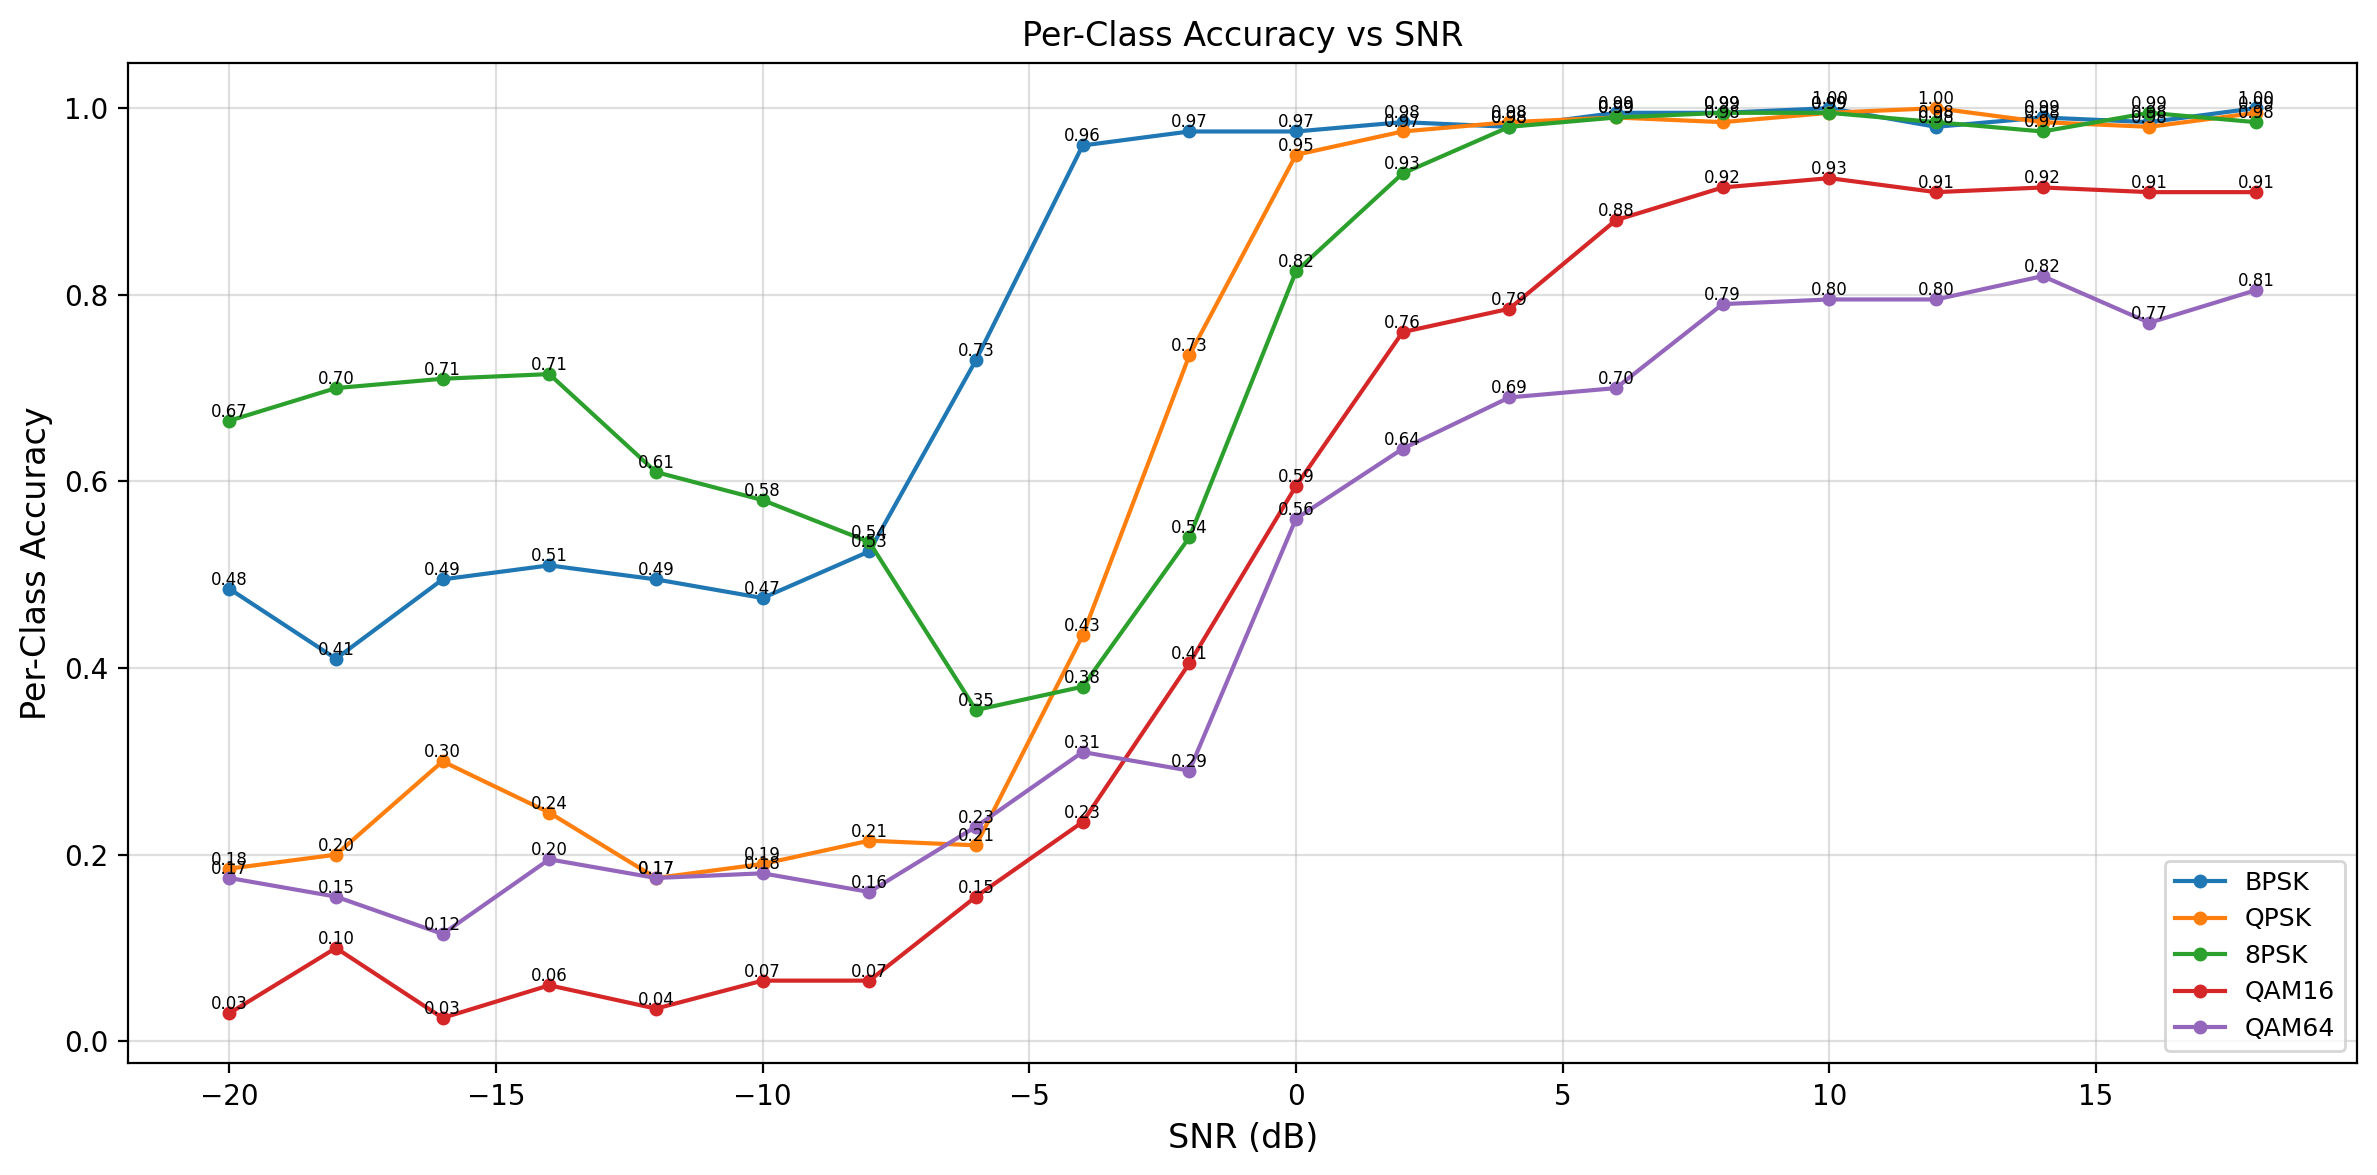

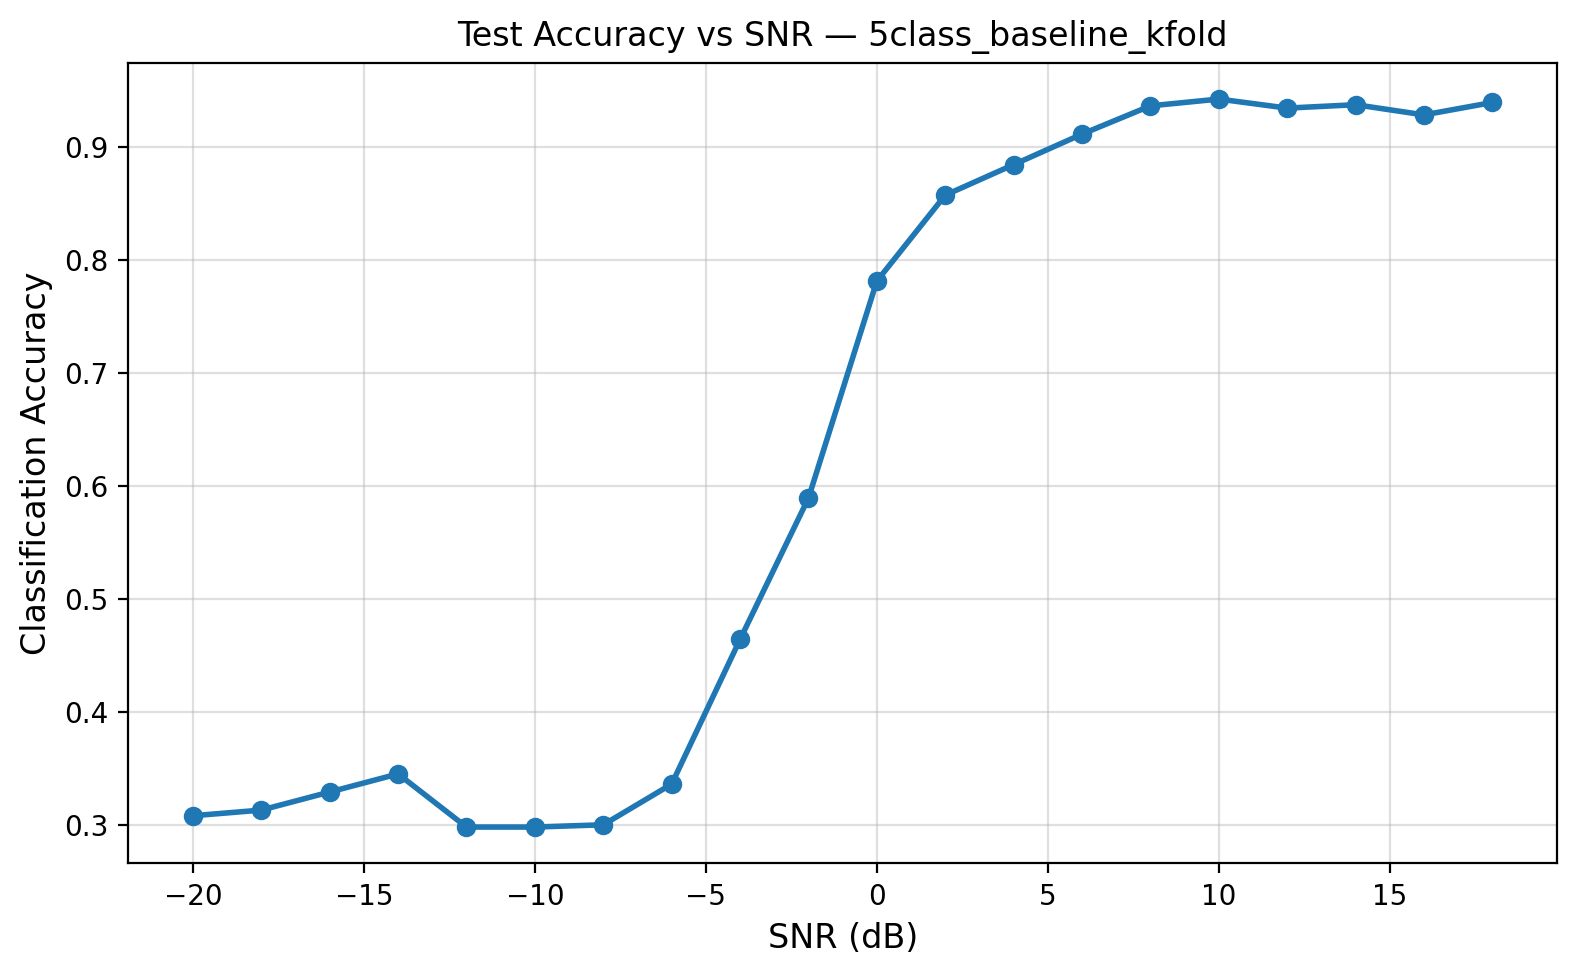


Attention — per-class accuracy (test set):
class  accuracy
 BPSK    0.7708
 QPSK    0.5447
 8PSK    0.5920
QAM16    0.6957
QAM64    0.4557

Attention — per-class accuracy vs SNR:


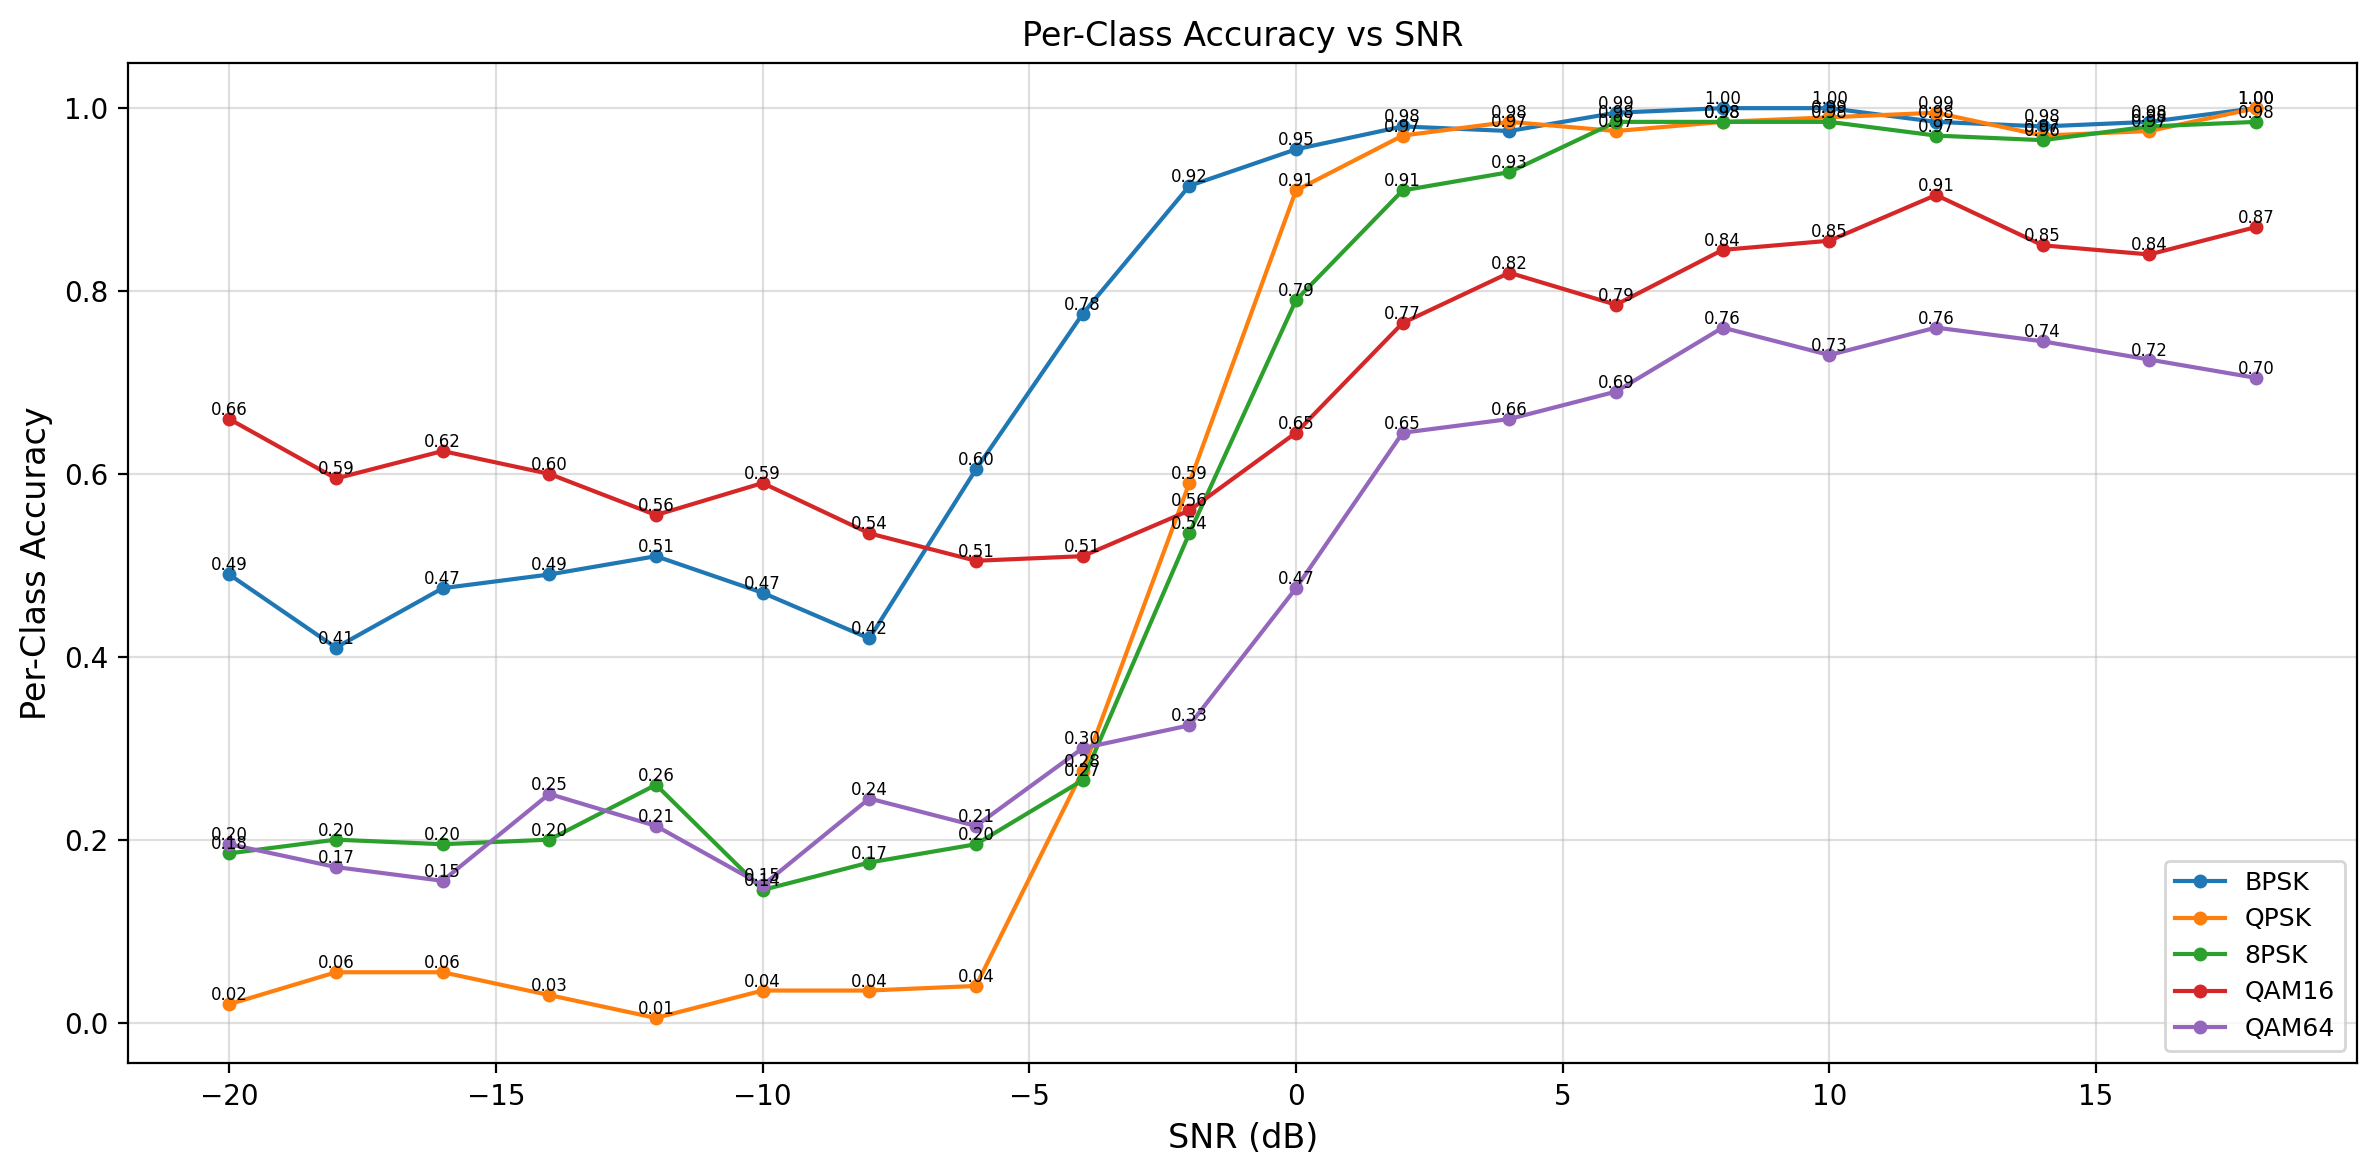

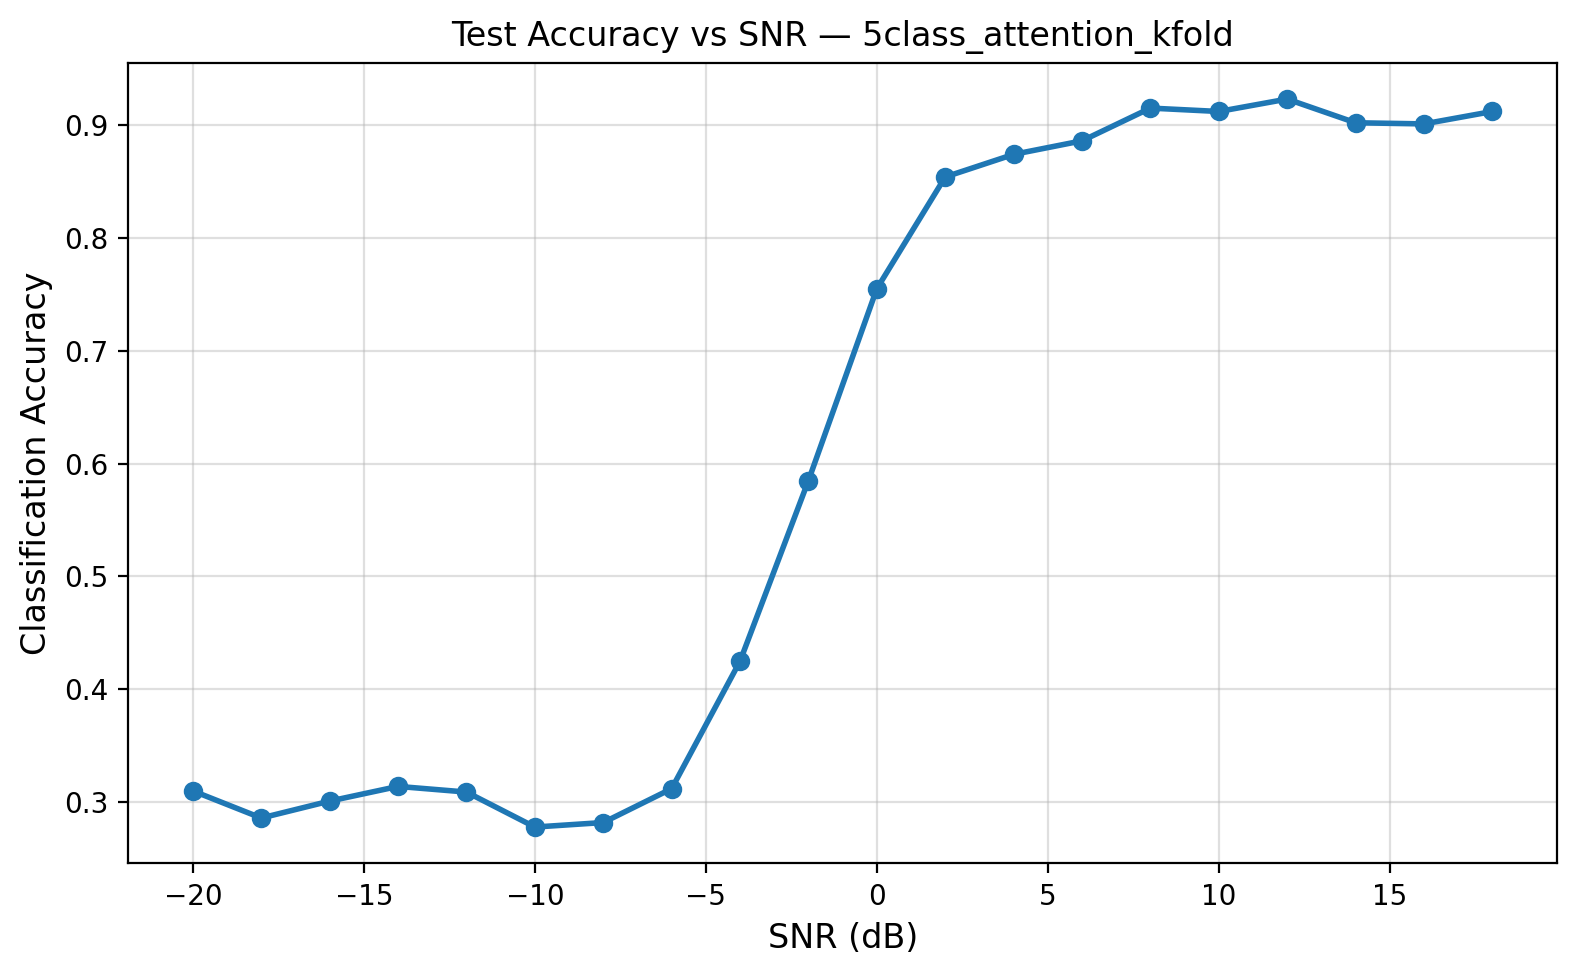


──────────────────────────────────────────────────
Per-class accuracy comparison (test set, best-fold models):
class  baseline  attention   delta
 BPSK    0.7973     0.7708 -0.0265
 QPSK    0.6365     0.5447 -0.0918
 8PSK    0.7722     0.5920 -0.1802
QAM16    0.4840     0.6957  0.2117
QAM64    0.4672     0.4557 -0.0115
──────────────────────────────────────────────────


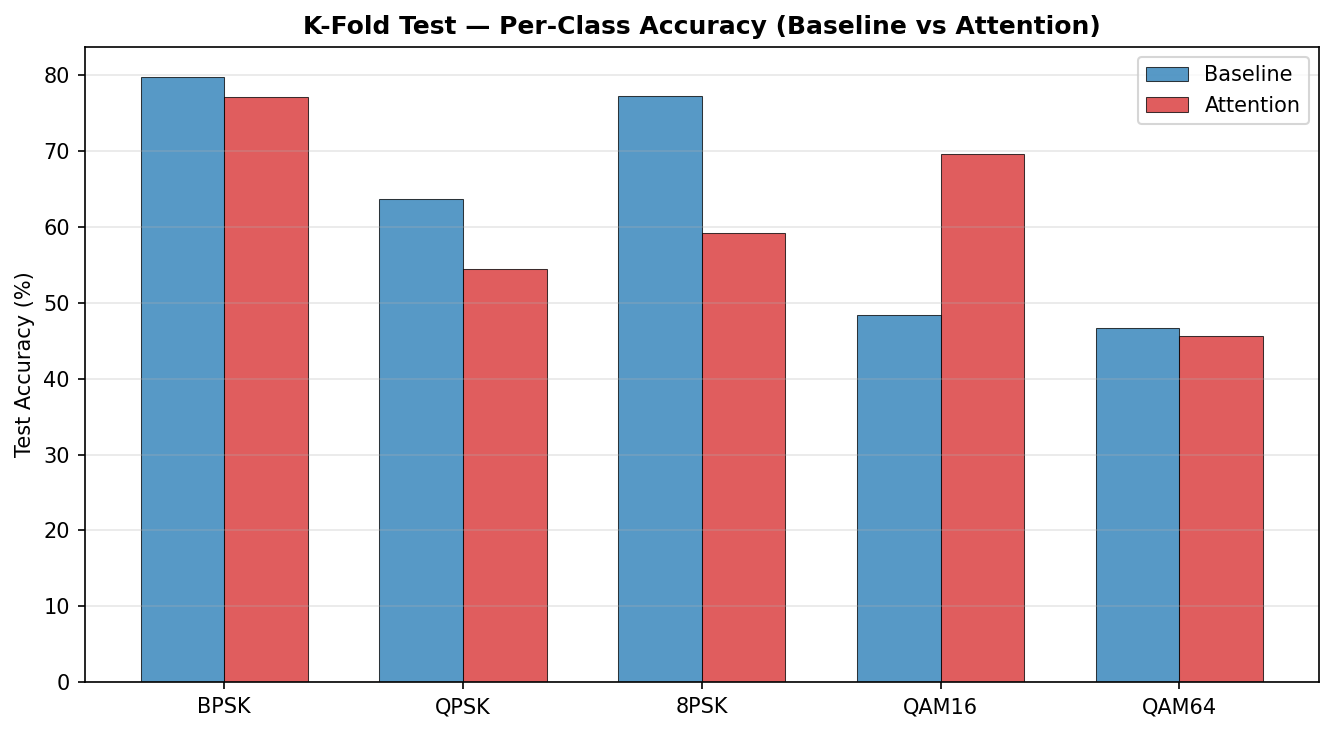

[SAVED] experiments/comparison_kfold/kfold_per_class_bar.png


In [8]:
 
# ── CELL 7: Per-class accuracy + per-class-vs-SNR plots ──────────────────────
 
import os, pandas as pd, numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
 
os.chdir('/kaggle/working/amr-5-class')
 
for tag, exp in [('Baseline', '5class_baseline_kfold'),
                 ('Attention', '5class_attention_kfold')]:
    # Per-class accuracy table
    csv_path = f'experiments/{exp}/kfold/test/per_class_acc.csv'
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f"\n{tag} — per-class accuracy (test set):")
        print(df.to_string(index=False))
 
    # Per-class-vs-SNR plot (generated by train_kfold.py already)
    img = f'experiments/{exp}/kfold/test/acc_per_class_vs_snr.png'
    if os.path.exists(img):
        print(f"\n{tag} — per-class accuracy vs SNR:")
        display(Image(img))
 
    # Acc vs SNR (overall)
    img2 = f'experiments/{exp}/kfold/test/acc_vs_snr.png'
    if os.path.exists(img2):
        display(Image(img2))
 
# Side-by-side per-class comparison
csv_b = 'experiments/5class_baseline_kfold/kfold/test/per_class_acc.csv'
csv_a = 'experiments/5class_attention_kfold/kfold/test/per_class_acc.csv'
if os.path.exists(csv_b) and os.path.exists(csv_a):
    df_b = pd.read_csv(csv_b).rename(columns={'accuracy': 'baseline'})
    df_a = pd.read_csv(csv_a).rename(columns={'accuracy': 'attention'})
    df_m = df_b.merge(df_a, on='class')
    df_m['delta'] = df_m['attention'] - df_m['baseline']
    df_m.to_csv('experiments/comparison_kfold/kfold_per_class_acc.csv', index=False)
    print(f"\n{'─'*50}")
    print("Per-class accuracy comparison (test set, best-fold models):")
    print(df_m.to_string(index=False))
    print(f"{'─'*50}")
 
    x  = np.arange(len(df_m))
    w  = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - w/2, df_m['baseline']  * 100, w, label='Baseline',
           color='#1f77b4', alpha=0.75, edgecolor='black', linewidth=0.5)
    ax.bar(x + w/2, df_m['attention'] * 100, w, label='Attention',
           color='#d62728', alpha=0.75, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(df_m['class'])
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('K-Fold Test — Per-Class Accuracy (Baseline vs Attention)',
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    p = 'experiments/comparison_kfold/kfold_per_class_bar.png'
    fig.savefig(p, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(p))
    print(f"[SAVED] {p}")
 


  Baseline — per-fold training history


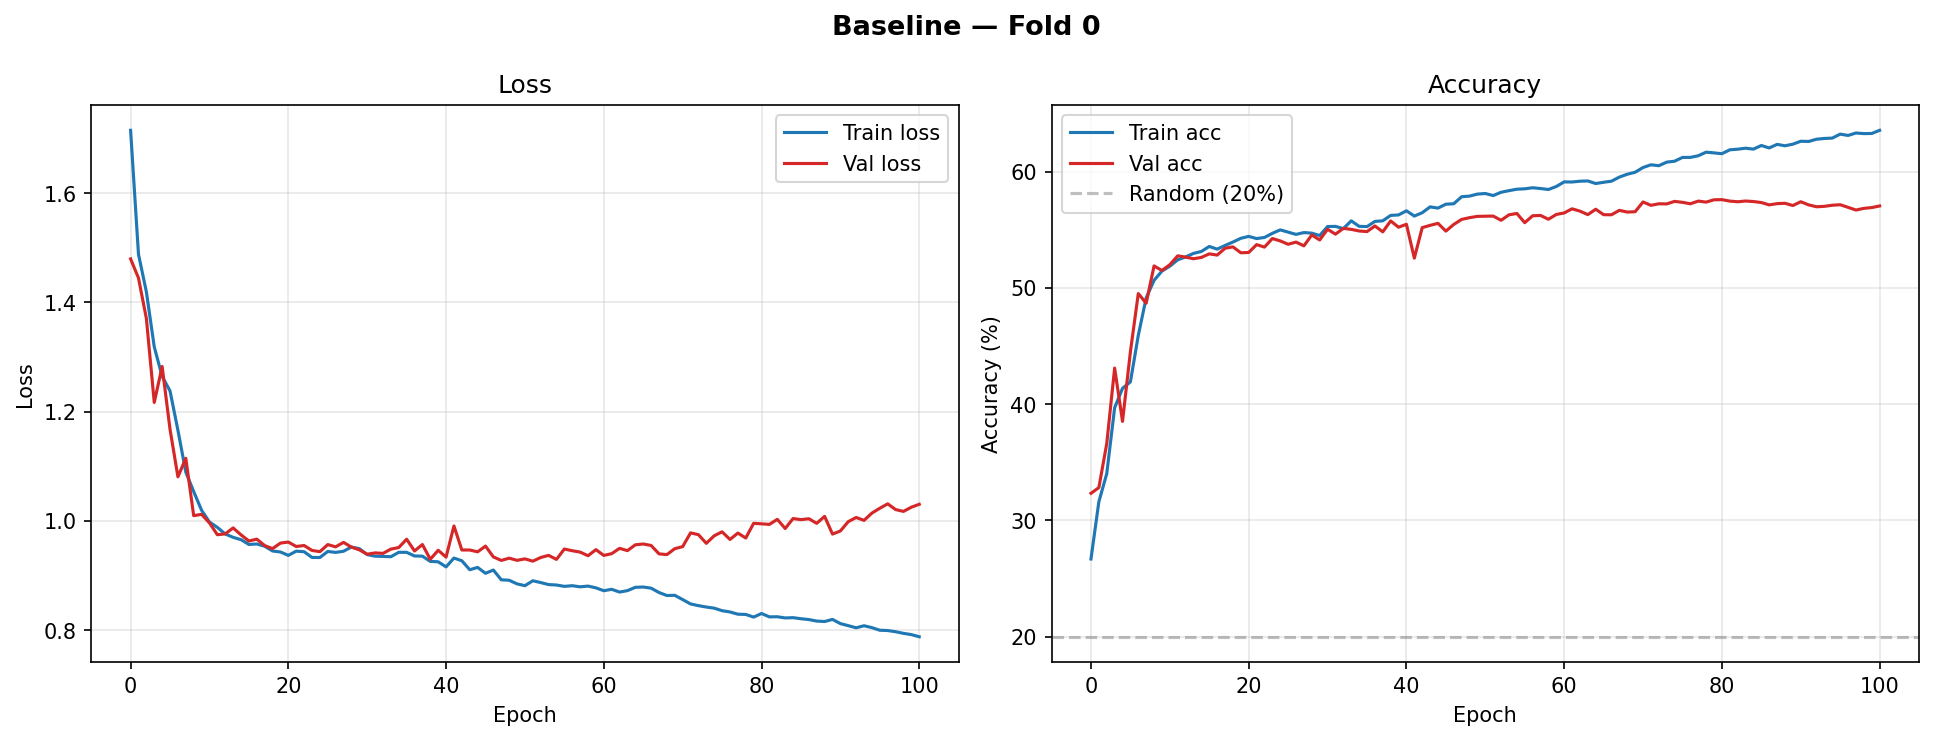

  Fold 0: best_epoch=80  val_acc=57.59%  val_loss=0.9946


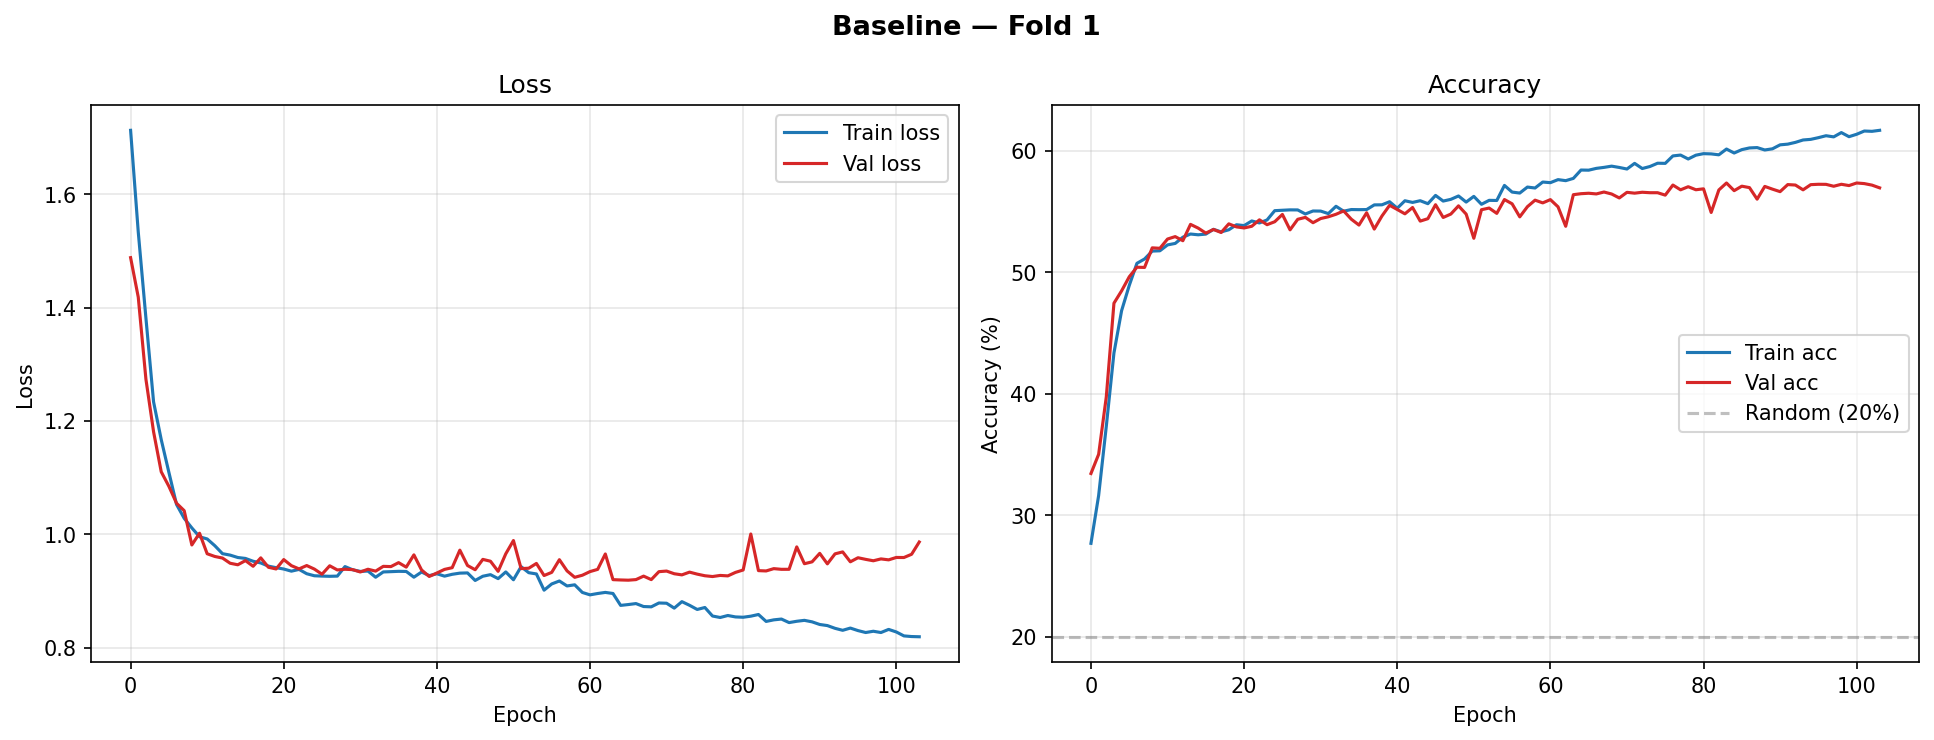

  Fold 1: best_epoch=83  val_acc=57.34%  val_loss=0.9353


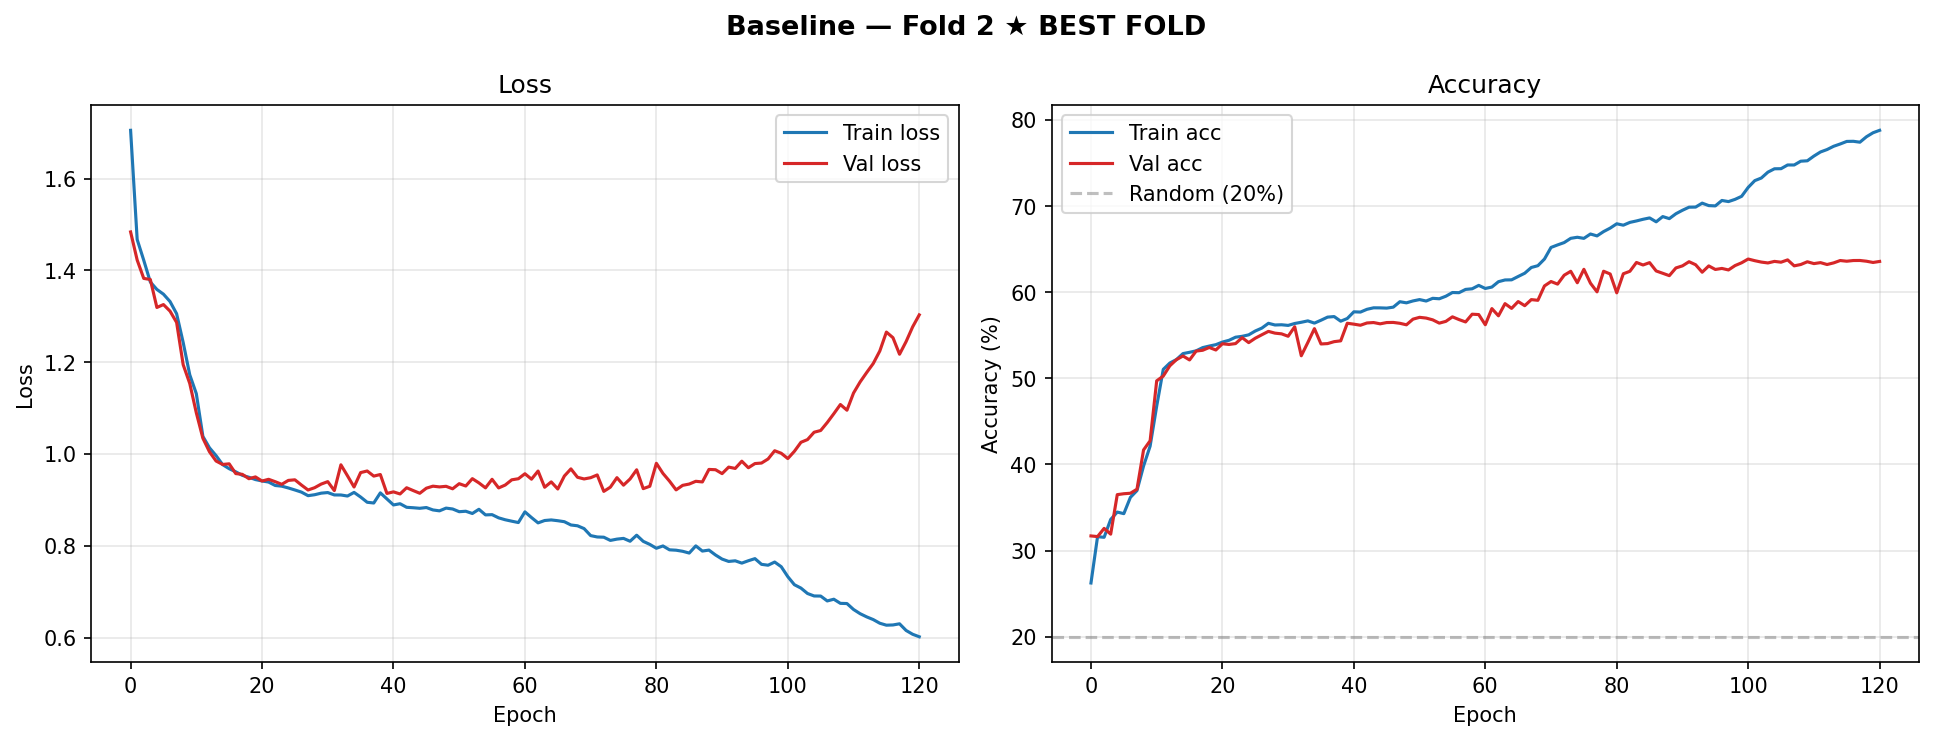

  Fold 2 ★ BEST FOLD: best_epoch=100  val_acc=63.86%  val_loss=0.9899


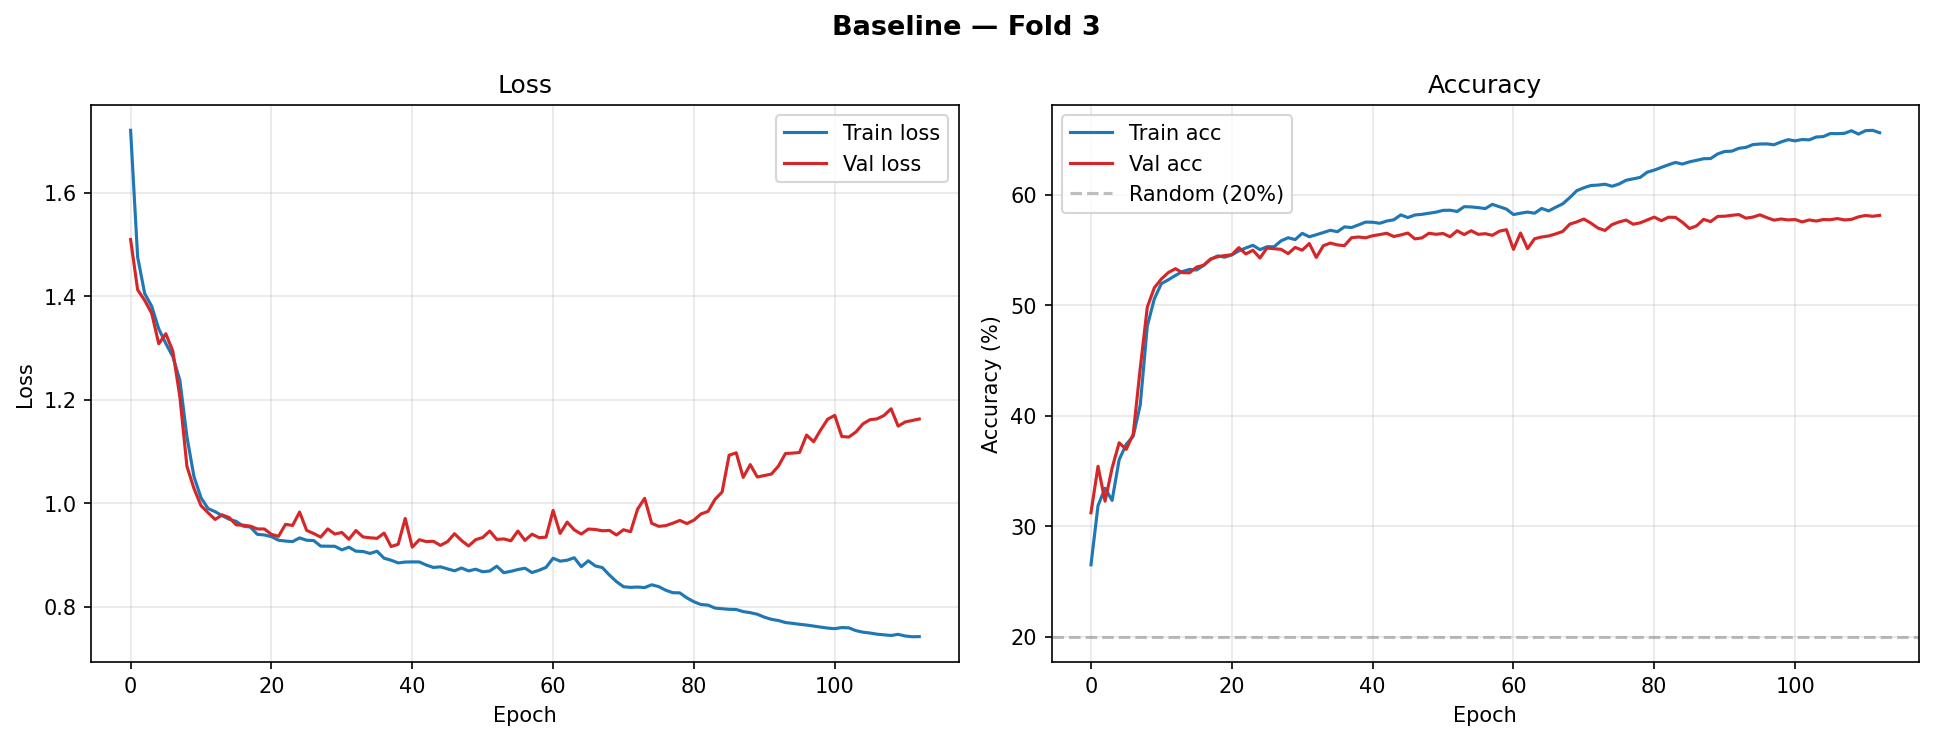

  Fold 3: best_epoch=92  val_acc=58.22%  val_loss=1.0720


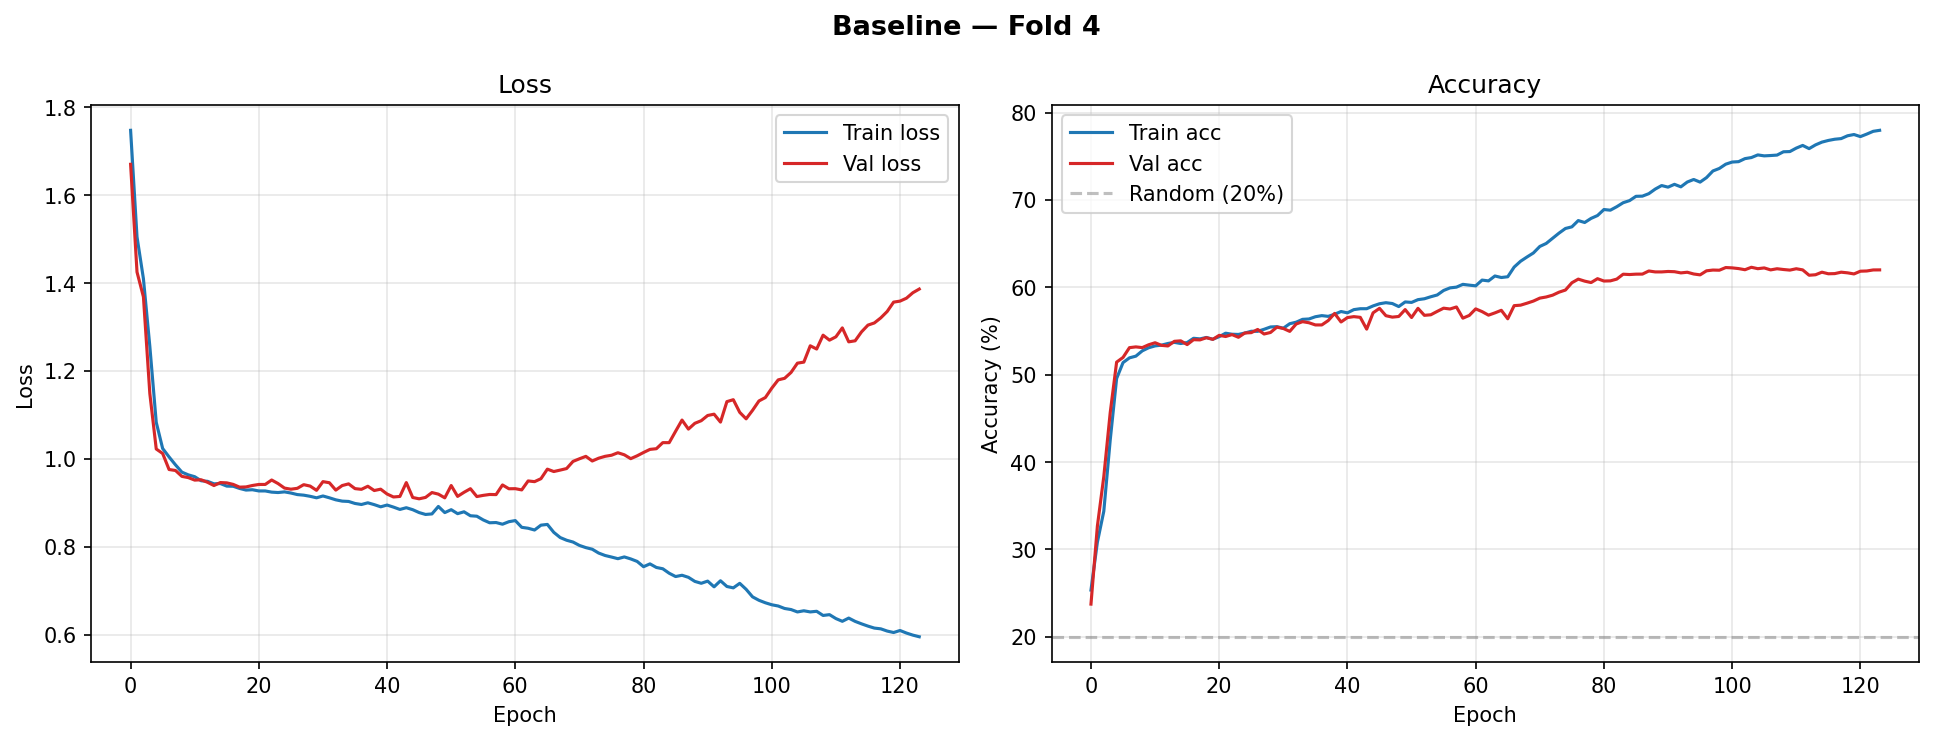

  Fold 4: best_epoch=103  val_acc=62.29%  val_loss=1.1966

  Attention — per-fold training history


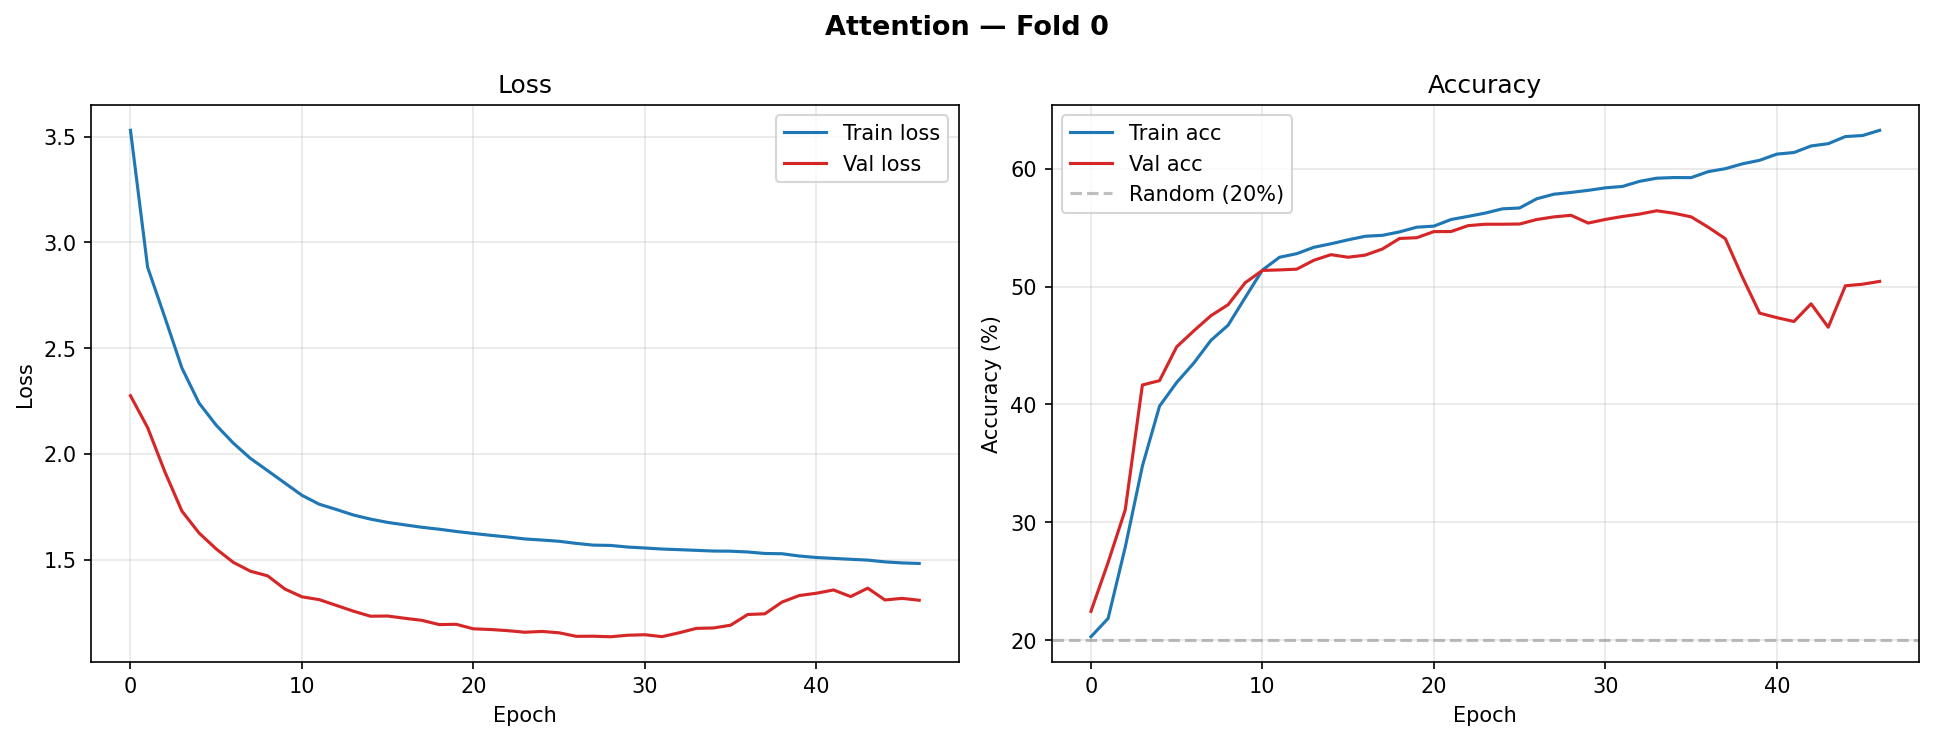

  Fold 0: best_epoch=33  val_acc=56.43%  val_loss=1.1743


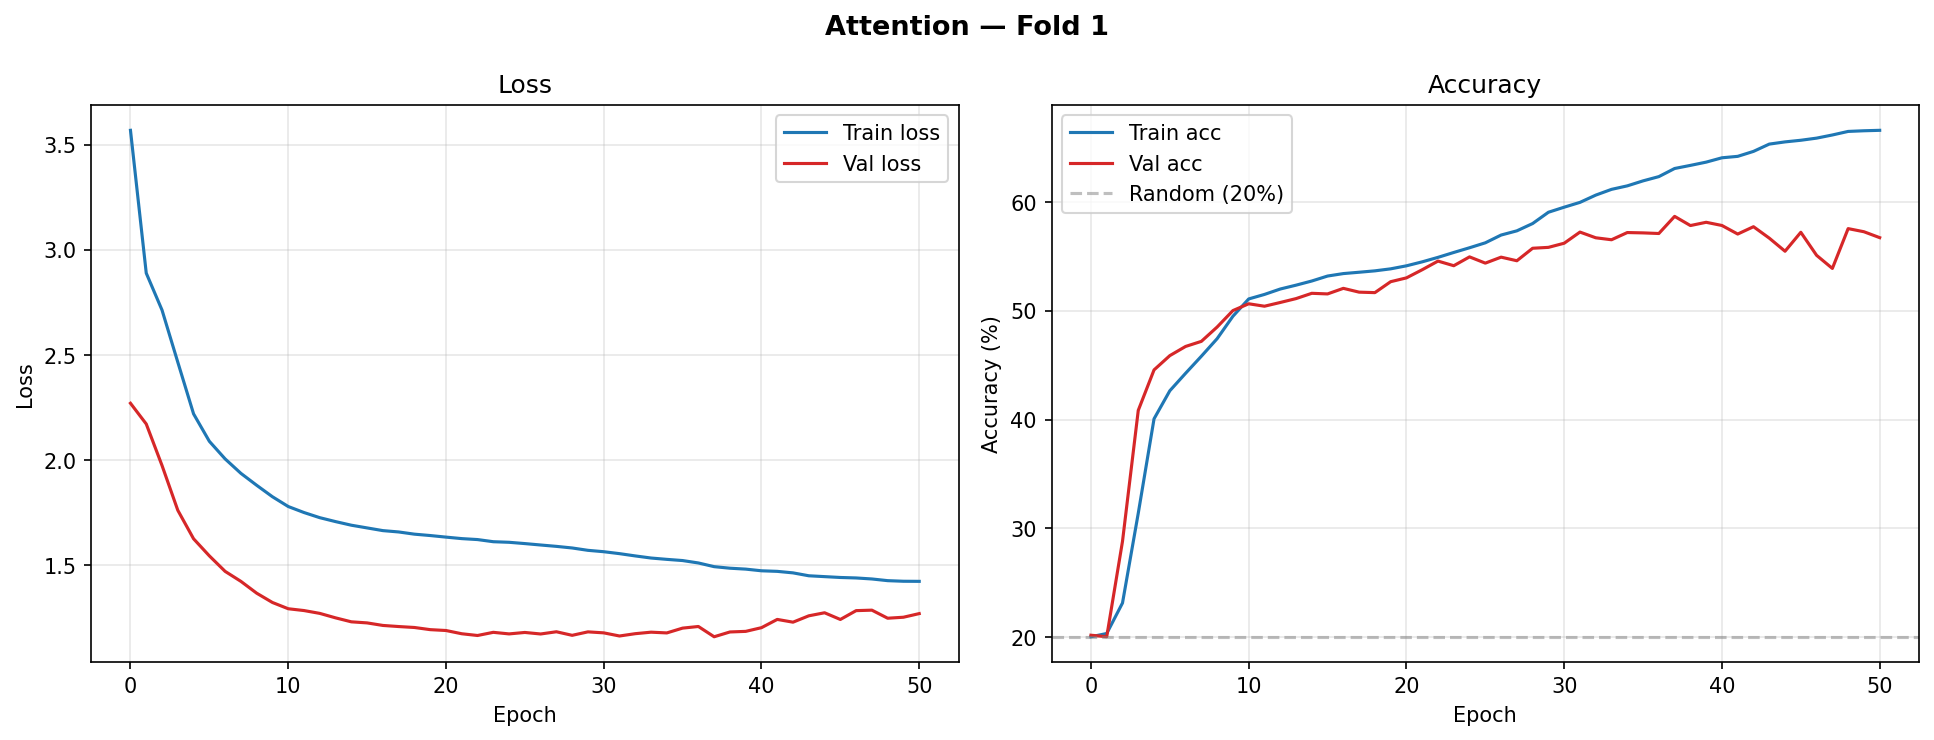

  Fold 1: best_epoch=37  val_acc=58.69%  val_loss=1.1614


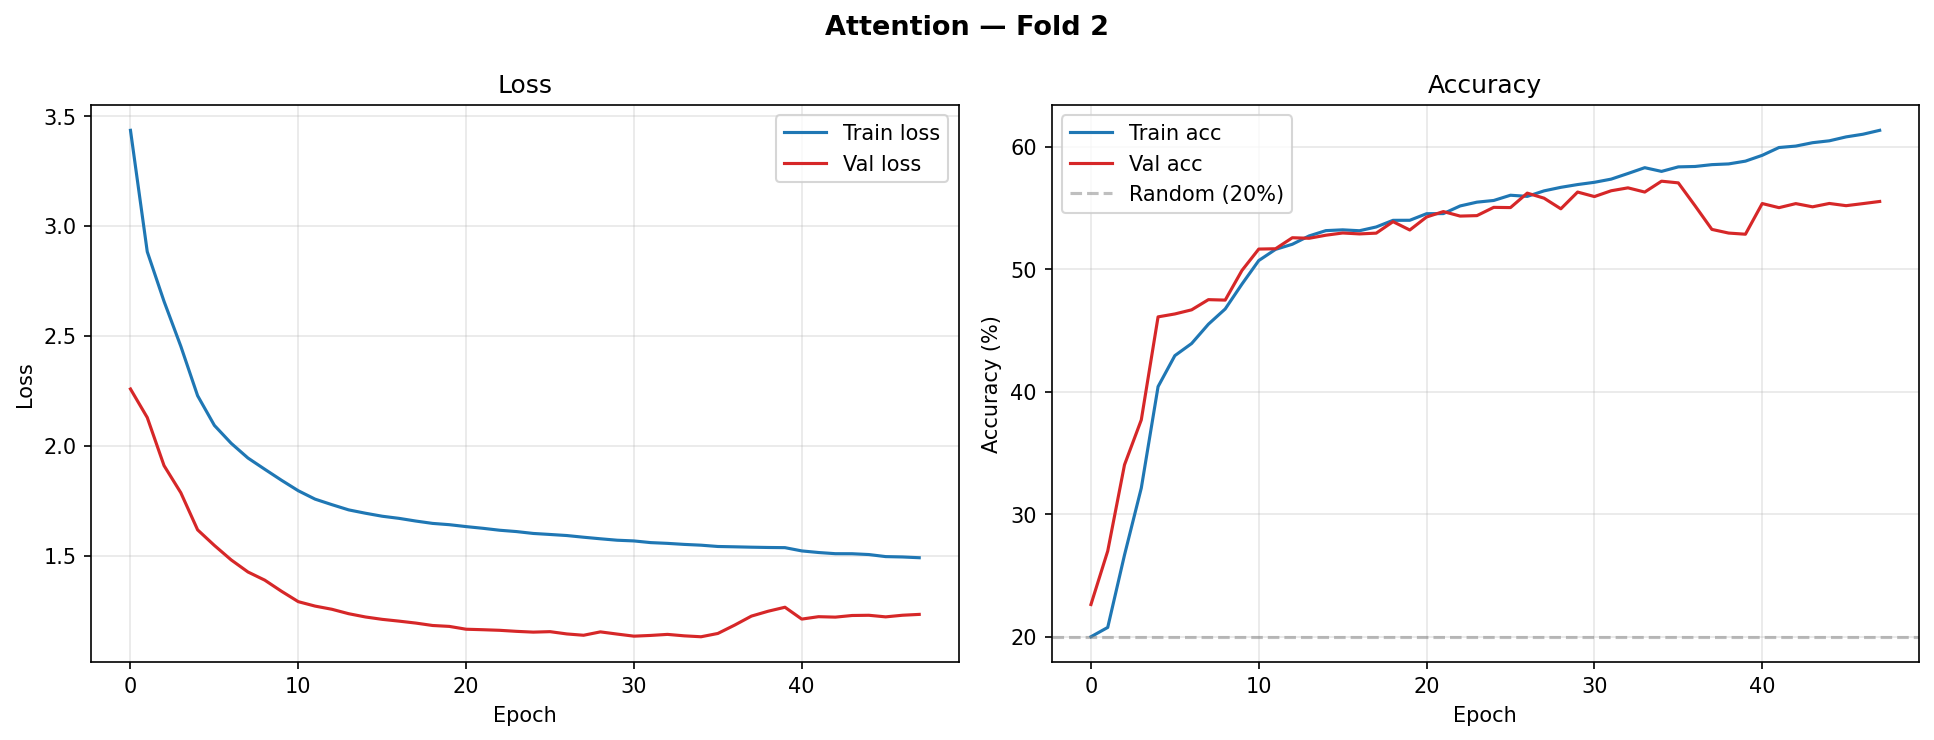

  Fold 2: best_epoch=34  val_acc=57.19%  val_loss=1.1302


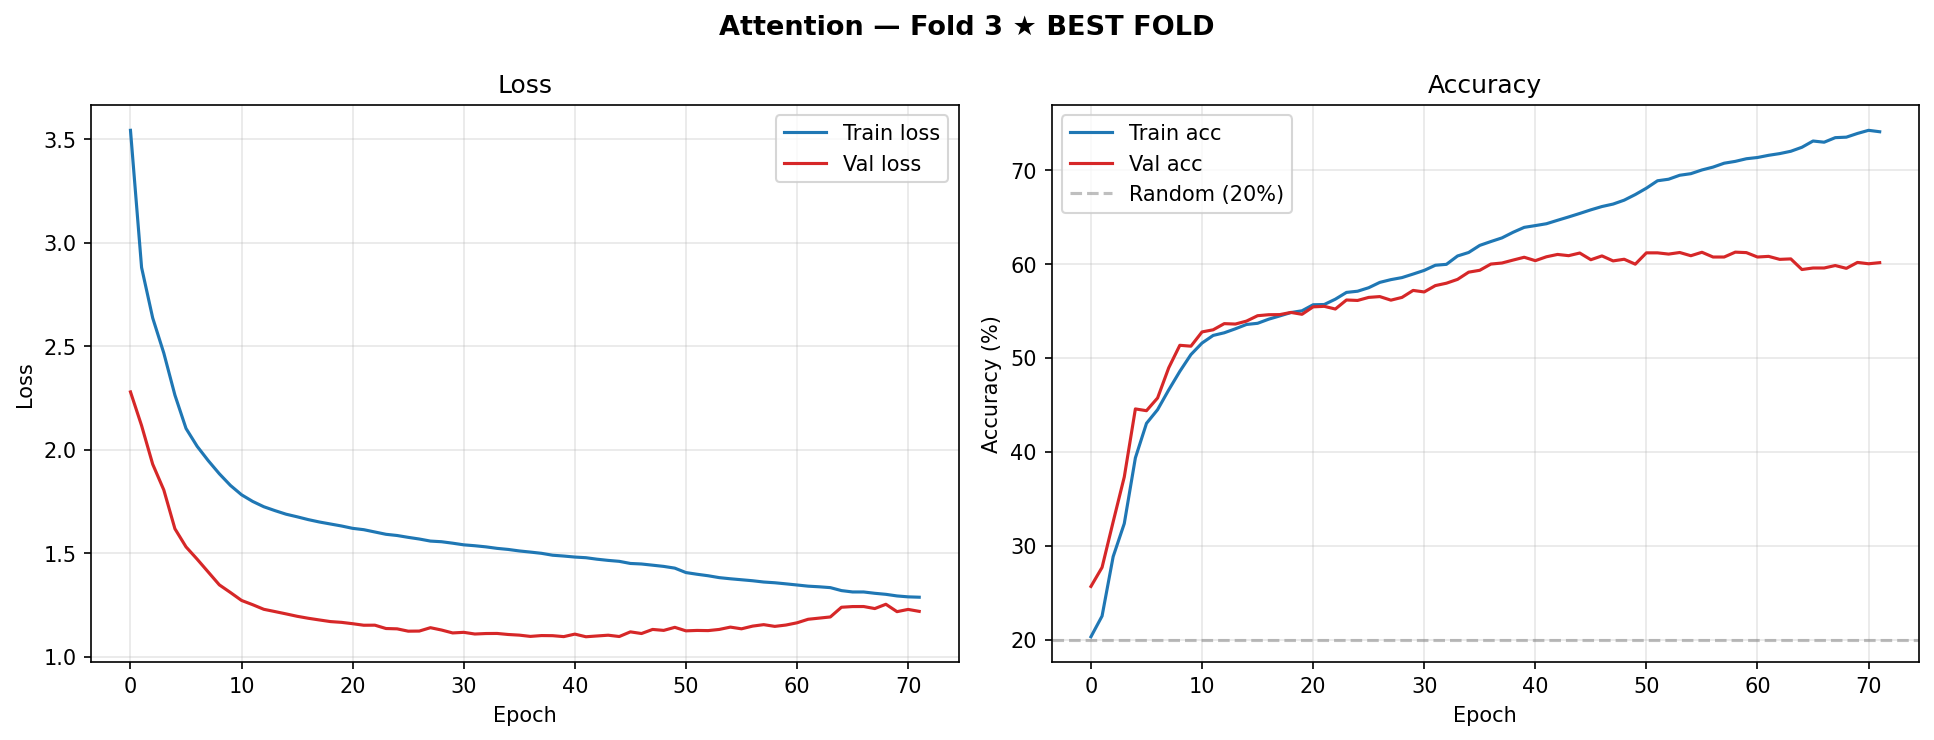

  Fold 3 ★ BEST FOLD: best_epoch=58  val_acc=61.27%  val_loss=1.1471


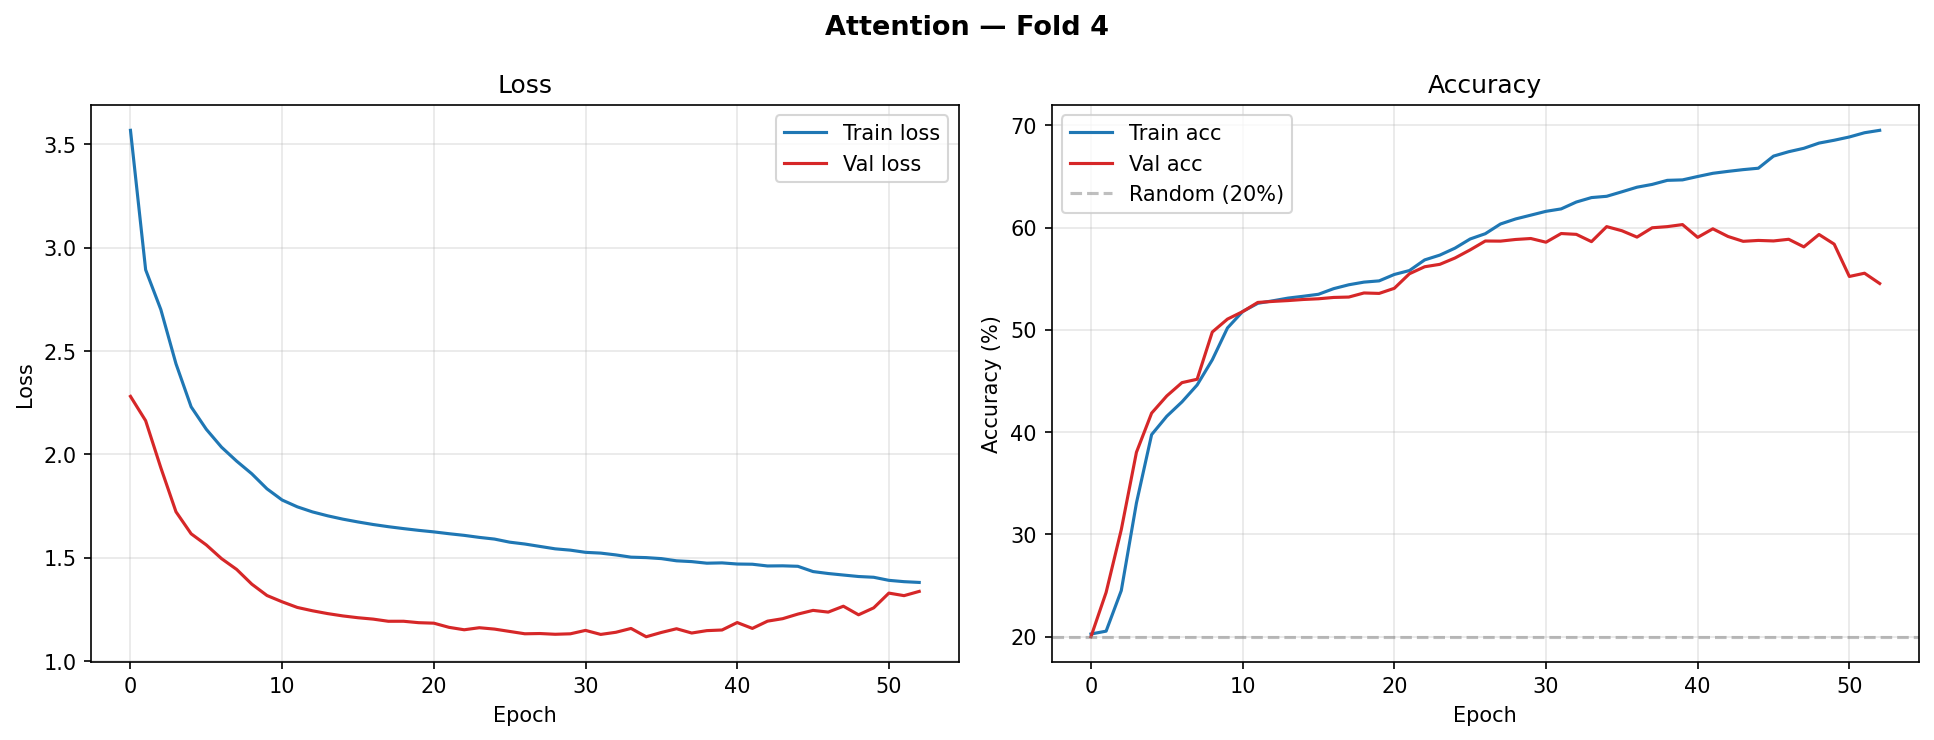

  Fold 4: best_epoch=39  val_acc=60.31%  val_loss=1.1501


In [9]:

# ── CELL 8: Per-fold training history plots ───────────────────────────────────
 
import os, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
import json
 
os.chdir('/kaggle/working/amr-5-class')
 
# Re-load summaries if needed
if 'summaries' not in dir() or not summaries:
    summaries = {}
    for tag, exp in [('Baseline', '5class_baseline_kfold'),
                     ('Attention', '5class_attention_kfold')]:
        path = f'experiments/{exp}/kfold/summary.json'
        if os.path.exists(path):
            with open(path) as f:
                summaries[tag] = json.load(f)
 
for tag, exp in [('Baseline', '5class_baseline_kfold'),
                 ('Attention', '5class_attention_kfold')]:
    best_fold = summaries.get(tag, {}).get('best_fold', -1)
    print(f"\n{'='*55}")
    print(f"  {tag} — per-fold training history")
    print(f"{'='*55}")
 
    for fold in range(5):
        csv_path = f'experiments/{exp}/kfold/fold_{fold}/history.csv'
        if not os.path.exists(csv_path):
            print(f"  [SKIP] fold_{fold} history.csv not found")
            continue
 
        log = pd.read_csv(csv_path)
        # Column names produced by CSVLogger: epoch, loss, accuracy, val_loss, val_accuracy
        acc_col     = next((c for c in log.columns if 'accuracy' in c and 'val' not in c), 'accuracy')
        val_acc_col = next((c for c in log.columns if 'val' in c and 'accuracy' in c), 'val_accuracy')
        epoch_col   = 'epoch' if 'epoch' in log.columns else log.columns[0]
 
        star = ' ★ BEST FOLD' if fold == best_fold else ''
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(f'{tag} — Fold {fold}{star}', fontsize=13, fontweight='bold')
 
        axes[0].plot(log[epoch_col], log['loss'],     color='#1f77b4', label='Train loss')
        axes[0].plot(log[epoch_col], log['val_loss'], color='#d62728', label='Val loss')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
 
        axes[1].plot(log[epoch_col], log[acc_col]     * 100, color='#1f77b4', label='Train acc')
        axes[1].plot(log[epoch_col], log[val_acc_col] * 100, color='#d62728', label='Val acc')
        axes[1].axhline(20, color='gray', linestyle='--', alpha=0.5, label='Random (20%)')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
        axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
 
        plt.tight_layout()
        save_path = f'experiments/comparison_kfold/{exp}_fold{fold}_history.png'
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
        display(Image(save_path))
 
        best_ep = log[val_acc_col].idxmax()
        print(f"  Fold {fold}{star}: best_epoch={log.loc[best_ep, epoch_col]}  "
              f"val_acc={log.loc[best_ep, val_acc_col]*100:.2f}%  "
              f"val_loss={log.loc[best_ep, 'val_loss']:.4f}")
 

In [10]:

# ── CELL 9: Final printed results summary ────────────────────────────────────
 
import os, json, numpy as np, pandas as pd
os.chdir('/kaggle/working/amr-5-class')
 
# Re-load everything
summaries, snr_accs = {}, {}
for tag, exp in [('Baseline', '5class_baseline_kfold'),
                 ('Attention', '5class_attention_kfold')]:
    s_path = f'experiments/{exp}/kfold/summary.json'
    c_path = f'experiments/{exp}/kfold/test/acc_per_snr.csv'
    if os.path.exists(s_path):
        with open(s_path) as f:
            summaries[tag] = json.load(f)
    if os.path.exists(c_path):
        df = pd.read_csv(c_path)
        snr_accs[tag] = dict(zip(df['snr'].astype(int), df['accuracy']))
 
print("=" * 65)
print("  FINAL RESULTS SUMMARY — 5-CLASS 5-FOLD CV")
print("=" * 65)
 
for tag in ['Baseline', 'Attention']:
    s = summaries.get(tag)
    if not s:
        continue
    mean_test = np.mean(list(snr_accs.get(tag, {0: float('nan')}).values()))
    print(f"\n  {tag}:")
    print(f"    Val  5-fold mean ± std : {s['mean_val_acc']*100:.2f}% ± {s['std_val_acc']*100:.2f}%")
    print(f"    Test (best fold_{s['best_fold']})  : {mean_test*100:.2f}%  (mean over all SNRs)")
    peak_snr = max(snr_accs.get(tag, {0: 0}), key=snr_accs.get(tag, {0: 0}).get)
    peak_acc = snr_accs.get(tag, {}).get(peak_snr, float('nan'))
    print(f"    Peak SNR accuracy      : {peak_acc*100:.2f}% at {peak_snr} dB")
 
names = list(summaries.keys())
if len(names) == 2:
    delta_val  = (summaries['Attention']['mean_val_acc'] -
                  summaries['Baseline']['mean_val_acc']) * 100
    mean_b = np.mean(list(snr_accs.get('Baseline',  {0: float('nan')}).values()))
    mean_a = np.mean(list(snr_accs.get('Attention', {0: float('nan')}).values()))
    delta_test = (mean_a - mean_b) * 100
    print(f"\n  Δ Attention − Baseline:")
    print(f"    Val  (mean fold acc) : {delta_val:+.2f}%")
    print(f"    Test (mean over SNR) : {delta_test:+.2f}%")
 
print("\n" + "=" * 65)
 

  FINAL RESULTS SUMMARY — 5-CLASS 5-FOLD CV

  Baseline:
    Val  5-fold mean ± std : 59.86% ± 2.68%
    Test (best fold_2)  : 63.14%  (mean over all SNRs)
    Peak SNR accuracy      : 94.20% at 10 dB

  Attention:
    Val  5-fold mean ± std : 58.78% ± 1.82%
    Test (best fold_3)  : 61.18%  (mean over all SNRs)
    Peak SNR accuracy      : 92.30% at 12 dB

  Δ Attention − Baseline:
    Val  (mean fold acc) : -1.08%
    Test (mean over SNR) : -1.96%



In [11]:

# ── CELL 10: Download all k-fold outputs as zip ───────────────────────────────
 
import zipfile, glob, os
from datetime import datetime
 
os.chdir('/kaggle/working/amr-5-class')
ts      = datetime.now().strftime('%Y%m%d_%H%M')
zip_out = f'/kaggle/working/kfold_results_{ts}.zip'
 
include_dirs = [
    'experiments/5class_baseline_kfold',
    'experiments/5class_attention_kfold',
    'experiments/comparison_kfold',
]
exts = ('.png', '.csv', '.h5', '.json', '.yaml')
 
with zipfile.ZipFile(zip_out, 'w', zipfile.ZIP_DEFLATED) as zf:
    for d in include_dirs:
        for f in glob.glob(f'{d}/**/*', recursive=True):
            if os.path.isfile(f) and f.endswith(exts):
                zf.write(f)
                print(f"  + {f}")
 
size = os.path.getsize(zip_out) / 1e6
print(f"\n[DONE] {zip_out}  ({size:.1f} MB)")
print("Download from Kaggle Output panel →")
 

  + experiments/5class_baseline_kfold/kfold/summary.json
  + experiments/5class_baseline_kfold/kfold/fold_2/total_acc.png
  + experiments/5class_baseline_kfold/kfold/fold_2/metrics.json
  + experiments/5class_baseline_kfold/kfold/fold_2/total_loss.png
  + experiments/5class_baseline_kfold/kfold/fold_2/history.csv
  + experiments/5class_baseline_kfold/kfold/fold_2/val_confusion.png
  + experiments/5class_baseline_kfold/kfold/fold_0/total_acc.png
  + experiments/5class_baseline_kfold/kfold/fold_0/metrics.json
  + experiments/5class_baseline_kfold/kfold/fold_0/total_loss.png
  + experiments/5class_baseline_kfold/kfold/fold_0/history.csv
  + experiments/5class_baseline_kfold/kfold/fold_0/val_confusion.png
  + experiments/5class_baseline_kfold/kfold/fold_1/total_acc.png
  + experiments/5class_baseline_kfold/kfold/fold_1/metrics.json
  + experiments/5class_baseline_kfold/kfold/fold_1/total_loss.png
  + experiments/5class_baseline_kfold/kfold/fold_1/history.csv
  + experiments/5class_baseline